# ExplainPlan-Vision
## Phase 4: Neuro-Symbolic Reasoning Agent

**Project:** ExplainPlan-Vision — Explainable Neuro-Symbolic Visual Planning Agent  
**Phase:** 4 of 7 — Neuro-Symbolic Reasoning  
**Depends on:** Phase 1 outputs (model checkpoint, class mappings, config)  
**Author:** Muhammad Aqib Javed


### What this phase builds

Phases 1–3 gave us a system that sees, explains, and recommends actions. Phase 4 adds the ability to *reason*. The distinction matters:

- Phase 3 applies rules: given a disease state, look up a matching action list.
- Phase 4 performs *inference*: traverse a knowledge graph to derive conclusions not explicitly stored anywhere, track state across time, and adapt reasoning to environmental context.

### System evolution

```
Phase 1   Image → Disease label + confidence
Phase 2   + Grad-CAM spatial explanation + SHAP + LIME
Phase 3   + Rule-based treatment plan + counterfactuals
Phase 4   + Knowledge graph inference + temporal memory
           + dynamic context-aware planning + causal reasoning
           + sequential decision trees + full reasoning traces
```

### Phase 4 modules

| Module | Class | Research concept |
|--------|-------|-----------------|
| Symbolic Fact Extractor | SymbolicFactExtractor | Neuro-symbolic grounding |
| Disease Knowledge Graph | DiseaseKnowledgeGraph | Graph relational reasoning |
| Neuro-Symbolic Reasoner | NeuroSymbolicReasoner | Forward-chaining inference |
| Context Engine | ContextEngine | Situation-aware adaptive planning |
| Temporal Memory | TemporalMemory | State tracking across observations |
| Causal Reasoner | CausalReasoner | Interventional and counterfactual reasoning |
| Decision Tree Planner | DecisionTreePlanner | Multi-step probabilistic look-ahead |
| NS Explainer | NSExplainer | Human-adaptive three-mode explanation |
| Unified Agent | run_ns_agent() | 12-stage pipeline orchestrator |

### Kaggle setup

Add Phase 1 outputs as input dataset. Update PHASE1_DIR in Cell 3.  
Add PlantVillage dataset as input. Update DATASET_PATH in Cell 3.  
No GPU training occurs — inference only. Expected runtime under 25 minutes.

## Cell 1 — Install dependencies

In [1]:
!pip install -q albumentations timm grad-cam networkx

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 56.4 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


## Cell 2 — Imports

In [2]:
import os, json, copy, random, warnings, textwrap, hashlib
from pathlib import Path
from datetime import datetime
from dataclasses import dataclass, field, asdict
from typing import List, Dict, Optional, Tuple, Any
from enum import Enum
from collections import defaultdict, deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import networkx as nx
import cv2
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.amp import autocast
import timm

import albumentations as A
from albumentations.pytorch import ToTensorV2

from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

warnings.filterwarnings("ignore")
os.environ["HF_TOKEN"] = os.environ.get("HF_TOKEN", "")

print(f"PyTorch  : {torch.__version__}")
print(f"NetworkX : {nx.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU      : {torch.cuda.get_device_name(0)}")

PyTorch  : 2.10.0+cu128
NetworkX : 3.6.1
CUDA     : True
GPU      : Tesla T4


## Cell 3 — Configuration

All preprocessing parameters are loaded from Phase 1's saved config.json.
Update PHASE1_DIR and DATASET_PATH to match your Kaggle input paths.

In [3]:
PHASE1_DIR   = "/kaggle/input/datasets/maqibniazi/explainplan-phase1-outputs"
DATASET_PATH = "/kaggle/input/datasets/emmarex/plantdisease/PlantVillage"

with open(f"{PHASE1_DIR}/outputs/checkpoints/config.json") as f:
    P1_CONFIG = json.load(f)

with open(f"{PHASE1_DIR}/outputs/checkpoints/class_mappings.json") as f:
    mappings = json.load(f)

class_to_idx = mappings["class_to_idx"]
idx_to_class = {int(k): v for k, v in mappings["idx_to_class"].items()}
classes      = mappings["classes"]
NUM_CLASSES  = mappings["num_classes"]

CONFIG = {
    "model_name"      : P1_CONFIG["model_name"],
    "image_size"      : P1_CONFIG["image_size"],
    "mean"            : P1_CONFIG["mean"],
    "std"             : P1_CONFIG["std"],
    "embedding_dim"   : P1_CONFIG["embedding_dim"],
    "dropout"         : P1_CONFIG["dropout"],
    "device"          : "cuda" if torch.cuda.is_available() else "cpu",
    "checkpoint_path" : f"{PHASE1_DIR}/outputs/checkpoints/best_model.pth",
    "severity_thresholds": {"high": 0.85, "medium": 0.60, "low": 0.0},
    "seed"            : 42,
    "output_dir"      : "outputs/ns_reasoning",
    "memory_capacity" : 20,
    "inference_depth" : 3,
    "confidence_gate" : 0.60,
    "lookahead_steps" : 4,
}

for sub in ["graphs", "traces", "trees", "reports", "figures"]:
    os.makedirs(f"{CONFIG['output_dir']}/{sub}", exist_ok=True)

random.seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])
torch.manual_seed(CONFIG["seed"])

print(f"Config loaded | Model: {CONFIG['model_name']} | Classes: {NUM_CLASSES} | Device: {CONFIG['device']}")

Config loaded | Model: efficientnet_b0 | Classes: 15 | Device: cuda


---
## Cell 4 — Vision model and inference pipeline

Exact copy of Phase 1 architecture loaded with the saved checkpoint.
Running in eval mode only — no gradients, no training.

In [4]:
inference_transform = A.Compose([
    A.Resize(CONFIG["image_size"], CONFIG["image_size"]),
    A.Normalize(mean=CONFIG["mean"], std=CONFIG["std"]),
    ToTensorV2()
])

def load_image_rgb(path):
    img = cv2.imread(path)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def preprocess_for_model(image_rgb):
    t = inference_transform(image=image_rgb)["image"]
    return t.unsqueeze(0).to(CONFIG["device"])

def preprocess_for_display(image_rgb):
    r = cv2.resize(image_rgb, (CONFIG["image_size"], CONFIG["image_size"]))
    return r.astype(np.float32) / 255.0


class PlantDiseaseModel(nn.Module):
    def __init__(self, model_name, num_classes, embedding_dim=512, dropout=0.3):
        super().__init__()
        self.backbone   = timm.create_model(model_name, pretrained=False, num_classes=0)
        backbone_out    = self.backbone.num_features
        self.classifier = nn.Sequential(
            nn.Linear(backbone_out, embedding_dim),
            nn.BatchNorm1d(embedding_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(embedding_dim, num_classes)
        )
    def forward(self, x):
        features = self.backbone(x)
        logits   = self.classifier(features)
        return logits, features

model = PlantDiseaseModel(
    model_name    = CONFIG["model_name"],
    num_classes   = NUM_CLASSES,
    embedding_dim = CONFIG["embedding_dim"],
    dropout       = CONFIG["dropout"]
).to(CONFIG["device"])
model.load_state_dict(torch.load(
    CONFIG["checkpoint_path"], map_location=CONFIG["device"], weights_only=True))
model.eval()

def estimate_severity(conf):
    t = CONFIG["severity_thresholds"]
    return "high" if conf >= t["high"] else "medium" if conf >= t["medium"] else "low"

def predict(image_rgb):
    model.eval()
    tensor = preprocess_for_model(image_rgb)
    with torch.no_grad():
        with autocast("cuda", enabled=torch.cuda.is_available()):
            logits, features = model(tensor)
        probs = torch.softmax(logits.float(), dim=1)[0]
    top_idx    = probs.argmax().item()
    confidence = probs[top_idx].item()
    label_name = idx_to_class[top_idx]
    if "___" in label_name:
        sp = label_name.split("___", 1)
        plant, disease_type = sp[0].replace("_"," ").strip(), sp[1].replace("_"," ").strip()
    else:
        tk = label_name.split("_")
        plant, disease_type = tk[0].strip(), " ".join(tk[1:]).strip()
    top3v, top3i = torch.topk(probs, k=min(3, NUM_CLASSES))
    return {
        "disease"      : label_name,
        "plant"        : plant,
        "disease_type" : disease_type,
        "confidence"   : round(confidence, 4),
        "severity"     : estimate_severity(confidence),
        "top3"         : [{"class": idx_to_class[i.item()], "confidence": round(v.item(),4)}
                          for v,i in zip(top3v, top3i)],
        "embedding"    : features[0].cpu().float().numpy(),
        "is_healthy"   : "healthy" in label_name.lower(),
    }

print(f"Model loaded: {sum(p.numel() for p in model.parameters()):,} parameters")

Model loaded: 4,672,139 parameters


## Cell 5 — Grad-CAM engine

Re-instantiated from Phase 2. The focus score and activation entropy from
the heatmap feed into the symbolic fact extractor as grounded spatial signals.

In [5]:
class GradCAMWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        logits, _ = self.model(x)
        return logits

class GradCAMEngine:
    def __init__(self, model, device):
        self.wrapped = GradCAMWrapper(model).to(device)
        self.wrapped.eval()
        self.cam = GradCAMPlusPlus(
            model=self.wrapped,
            target_layers=[self.wrapped.model.backbone.conv_head]
        )
    def generate(self, image_rgb, target_class_idx=None):
        tensor    = preprocess_for_model(image_rgb)
        rgb_float = preprocess_for_display(image_rgb)
        targets   = [ClassifierOutputTarget(target_class_idx)] if target_class_idx is not None else None
        heatmap   = self.cam(input_tensor=tensor, targets=targets)[0]
        overlay   = show_cam_on_image(rgb_float, heatmap, use_rgb=True)
        return heatmap, overlay

gradcam_engine = GradCAMEngine(model, CONFIG["device"])
print("GradCAM engine ready")

GradCAM engine ready


## Cell 6 — Symbolic Fact Extractor

### Research concept: neuro-symbolic grounding

The fact extractor bridges the neural and symbolic worlds. It converts
continuous-valued neural outputs — confidence floats, heatmap arrays,
embedding vectors — into discrete typed symbolic predicates that a logic
engine can reason over.

This grounding step is what makes the system genuinely neuro-symbolic. Without
explicit grounding, symbolic rules cannot fire on neural outputs. With it, every
downstream inference is fully traceable to a specific measurement from the vision
model. Three extraction passes run sequentially: vision facts from the prediction
dict, spatial facts from the Grad-CAM heatmap, and derived facts computed from
the previous two.

In [6]:
@dataclass
class SymbolicFact:
    predicate  : str
    arguments  : List[str]
    confidence : float
    source     : str        # vision_model | gradcam | embedding | derived
    timestamp  : str = field(default_factory=lambda: datetime.now().isoformat())
    def __str__(self):
        return f"{self.predicate}({', '.join(self.arguments)}) [{self.confidence:.3f} via {self.source}]"
    def to_dict(self): return asdict(self)


class SymbolicFactExtractor:
    PATHOGEN_GROUPS = {
        "fungal"   : ["Early blight","Late blight","Leaf Mold","Septoria leaf spot","Target Spot"],
        "bacterial": ["Bacterial spot"],
        "viral"    : ["Tomato YellowLeaf  Curl Virus","Tomato mosaic virus"],
        "pest"     : ["Spider mites Two spotted spider mite"],
        "oomycete" : ["Late blight"],
        "none"     : ["healthy"],
    }
    ENVIRONMENT_MAP = {
        "fungal"   : {"humidity":"high","temperature":"warm","wetness":"high"},
        "oomycete" : {"humidity":"high","temperature":"cool","wetness":"high"},
        "bacterial": {"humidity":"high","temperature":"warm","wetness":"high"},
        "viral"    : {"humidity":"any","temperature":"any","wetness":"low"},
        "pest"     : {"humidity":"low","temperature":"hot","wetness":"low"},
        "none"     : {"humidity":"any","temperature":"any","wetness":"any"},
    }

    def extract(self, prediction, heatmap):
        facts = []
        facts.extend(self._vision_facts(prediction))
        facts.extend(self._spatial_facts(heatmap, prediction["confidence"]))
        facts.extend(self._derived_facts(facts, prediction))
        return facts

    def _vision_facts(self, pred):
        conf = pred["confidence"]
        dt   = pred["disease_type"]
        pt   = self._get_pathogen_type(dt)
        runner_up_cls  = pred["top3"][1]["class"] if len(pred["top3"]) > 1 else "none"
        runner_up_conf = pred["top3"][1]["confidence"] if len(pred["top3"]) > 1 else 0.0
        return [
            SymbolicFact("disease_is",       [pred["disease"]],            conf,        "vision_model"),
            SymbolicFact("disease_type_is",  [dt],                         conf,        "vision_model"),
            SymbolicFact("plant_is",         [pred["plant"]],              conf,        "vision_model"),
            SymbolicFact("severity_is",      [pred["severity"]],           conf,        "vision_model"),
            SymbolicFact("confidence_level", [self._conf_level(conf)],     conf,        "vision_model"),
            SymbolicFact("pathogen_type_is", [pt],                         conf,        "vision_model"),
            SymbolicFact("is_healthy",       [str(pred["is_healthy"])],    conf,        "vision_model"),
            SymbolicFact("runner_up_is",     [runner_up_cls],              runner_up_conf, "vision_model"),
        ]

    def _spatial_facts(self, heatmap, conf):
        focus   = float((heatmap >= np.percentile(heatmap, 80)).mean())
        spread  = ("localised" if focus < 0.06 else
                   "moderate"  if focus < 0.15 else "widespread")
        h_flat  = heatmap.flatten() + 1e-8
        h_norm  = h_flat / h_flat.sum()
        entropy = float(-np.sum(h_norm * np.log(h_norm)))
        peak    = float(heatmap.max())
        return [
            SymbolicFact("infection_spread",   [spread],              conf, "gradcam"),
            SymbolicFact("focus_score",        [f"{focus:.4f}"],      conf, "gradcam"),
            SymbolicFact("activation_entropy", [f"{entropy:.4f}"],    conf, "gradcam"),
            SymbolicFact("peak_activation",    [f"{peak:.4f}"],       conf, "gradcam"),
            SymbolicFact("spatial_complexity", [self._complexity(entropy)], conf, "gradcam"),
        ]

    def _derived_facts(self, existing, pred):
        fact_map = {f.predicate: f.arguments[0] for f in existing}
        pt    = fact_map.get("pathogen_type_is","unknown")
        sev   = fact_map.get("severity_is","low")
        spread= fact_map.get("infection_spread","localised")
        conf  = pred["confidence"]
        derived = []

        treatment_map = {
            "fungal"   :"fungicide","oomycete":"systemic_fungicide",
            "bacterial":"bactericide","viral":"vector_control",
            "pest"     :"miticide","none":"monitoring_only",
        }
        derived.append(SymbolicFact("treatment_class",
            [treatment_map.get(pt,"expert_consultation")], conf, "derived"))

        spread_risk_map = {"Late blight":"critical","Tomato YellowLeaf  Curl Virus":"critical"}
        disease_type    = pred["disease_type"]
        spread_risk     = spread_risk_map.get(disease_type,
                          "high" if spread=="widespread" else "medium")
        derived.append(SymbolicFact("spread_risk", [spread_risk], conf, "derived"))

        urgency_score = (conf
            * {"high":3,"medium":2,"low":1}.get(sev,1)
            * {"critical":3,"high":2,"medium":1.5,"low":1,"none":0}.get(spread_risk,1))
        urgency = ("immediate" if urgency_score >= 4.5 else
                   "high"      if urgency_score >= 3.0 else
                   "medium"    if urgency_score >= 1.5 else
                   "low"       if not pred["is_healthy"] else "none")
        derived.append(SymbolicFact("urgency_level", [urgency],              conf, "derived"))
        derived.append(SymbolicFact("urgency_score", [f"{urgency_score:.4f}"],conf,"derived"))

        for env_key, env_val in self.ENVIRONMENT_MAP.get(pt,{}).items():
            derived.append(SymbolicFact(f"favoured_by_{env_key}", [env_val], conf, "derived"))

        needs_iso  = spread_risk in ["critical"] or (spread=="widespread" and sev=="high")
        needs_chem = pt not in ["none"] and not pred["is_healthy"]
        derived.append(SymbolicFact("requires_isolation", [str(needs_iso)],  conf, "derived"))
        derived.append(SymbolicFact("requires_chemical",  [str(needs_chem)], conf, "derived"))
        return derived

    def _get_pathogen_type(self, disease_type):
        for pt, diseases in self.PATHOGEN_GROUPS.items():
            if any(d.lower() in disease_type.lower() or disease_type.lower() in d.lower()
                   for d in diseases):
                return pt
        return "unknown"

    def _conf_level(self, conf):
        return ("very_high" if conf >= 0.92 else "high" if conf >= 0.80 else
                "moderate" if conf >= 0.60 else "low")

    def _complexity(self, entropy):
        return "complex" if entropy > 4.0 else "moderate" if entropy > 2.5 else "simple"


extractor = SymbolicFactExtractor()
print("SymbolicFactExtractor ready")
print("  Passes: vision (8 facts) + spatial (5 facts) + derived (dynamic)")

SymbolicFactExtractor ready
  Passes: vision (8 facts) + spatial (5 facts) + derived (dynamic)


## Cell 7 — Disease Knowledge Graph

### Research concept: graph-based relational reasoning

A knowledge graph represents the disease domain as a network of typed relations
between entities. Unlike a lookup table, the graph allows the reasoner to traverse
multi-hop paths and derive conclusions that are not explicitly stored.

For example: Late_blight --[caused_by]--> Phytophthora_infestans --[belongs_to]-->
Oomycetes --[treated_by]--> Metalaxyl. A path query from Late_blight to Metalaxyl
traverses this chain and justifies the treatment with an explicit reasoning path.

Node types: disease, pathogen, treatment, environment  
Edge types: caused_by, treated_by, favoured_by, worsened_by, confused_with

In [7]:
class DiseaseKnowledgeGraph:
    def __init__(self):
        self.G = nx.DiGraph()
        self._build()

    def _build(self):
        G = self.G
        diseases = {
            "Early_blight"          :{"type":"disease","pathogen_type":"fungal",  "spread":"medium",  "host":["tomato","potato"]},
            "Late_blight"           :{"type":"disease","pathogen_type":"oomycete","spread":"critical","host":["tomato","potato"]},
            "Bacterial_spot"        :{"type":"disease","pathogen_type":"bacterial","spread":"high",   "host":["tomato","pepper"]},
            "Septoria_leaf_spot"    :{"type":"disease","pathogen_type":"fungal",  "spread":"medium",  "host":["tomato"]},
            "Leaf_Mold"             :{"type":"disease","pathogen_type":"fungal",  "spread":"medium",  "host":["tomato"]},
            "Target_Spot"           :{"type":"disease","pathogen_type":"fungal",  "spread":"medium",  "host":["tomato"]},
            "Spider_mites"          :{"type":"disease","pathogen_type":"pest",    "spread":"high",    "host":["tomato"]},
            "YellowLeaf_Curl_Virus" :{"type":"disease","pathogen_type":"viral",   "spread":"critical","host":["tomato"]},
            "Mosaic_Virus"          :{"type":"disease","pathogen_type":"viral",   "spread":"high",    "host":["tomato"]},
            "Healthy"               :{"type":"disease","pathogen_type":"none",    "spread":"none",    "host":["tomato","potato","pepper"]},
        }
        pathogens = {
            "Alternaria_solani"     :{"type":"pathogen","kingdom":"fungi"},
            "Phytophthora_infestans":{"type":"pathogen","kingdom":"oomycetes"},
            "Xanthomonas_spp"       :{"type":"pathogen","kingdom":"bacteria"},
            "Septoria_lycopersici"  :{"type":"pathogen","kingdom":"fungi"},
            "Passalora_fulva"       :{"type":"pathogen","kingdom":"fungi"},
            "Corynespora_cassiicola":{"type":"pathogen","kingdom":"fungi"},
            "Tetranychus_urticae"   :{"type":"pathogen","kingdom":"arthropods"},
            "TYLCV"                 :{"type":"pathogen","kingdom":"virus"},
            "ToMV"                  :{"type":"pathogen","kingdom":"virus"},
        }
        treatments = {
            "Copper_fungicide"    :{"type":"treatment","category":"fungicide",   "mode":"contact"},
            "Chlorothalonil"      :{"type":"treatment","category":"fungicide",   "mode":"contact"},
            "Mancozeb"            :{"type":"treatment","category":"fungicide",   "mode":"contact"},
            "Metalaxyl"           :{"type":"treatment","category":"fungicide",   "mode":"systemic"},
            "Copper_bactericide"  :{"type":"treatment","category":"bactericide", "mode":"contact"},
            "Imidacloprid"        :{"type":"treatment","category":"insecticide", "mode":"systemic"},
            "Abamectin"           :{"type":"treatment","category":"miticide",    "mode":"contact"},
            "Physical_removal"    :{"type":"treatment","category":"cultural",    "mode":"physical"},
            "Drip_irrigation"     :{"type":"treatment","category":"cultural",    "mode":"environmental"},
            "Isolation"           :{"type":"treatment","category":"containment", "mode":"physical"},
            "Monitoring"          :{"type":"treatment","category":"surveillance","mode":"observational"},
        }
        envs = {
            "High_humidity"  :{"type":"environment"},"High_temperature":{"type":"environment"},
            "Cool_temperature":{"type":"environment"},"Leaf_wetness"    :{"type":"environment"},
            "Low_humidity"   :{"type":"environment"},"Whitefly_vector" :{"type":"environment"},
            "Aphid_vector"   :{"type":"environment"},
        }
        for d,a in {**diseases,**pathogens,**treatments,**envs}.items():
            G.add_node(d, **a)

        dp_edges = [
            ("Early_blight","Alternaria_solani","caused_by"),
            ("Late_blight","Phytophthora_infestans","caused_by"),
            ("Bacterial_spot","Xanthomonas_spp","caused_by"),
            ("Septoria_leaf_spot","Septoria_lycopersici","caused_by"),
            ("Leaf_Mold","Passalora_fulva","caused_by"),
            ("Target_Spot","Corynespora_cassiicola","caused_by"),
            ("Spider_mites","Tetranychus_urticae","caused_by"),
            ("YellowLeaf_Curl_Virus","TYLCV","caused_by"),
            ("Mosaic_Virus","ToMV","caused_by"),
        ]
        dt_edges = [
            ("Early_blight","Copper_fungicide","treated_by",0.90),
            ("Early_blight","Chlorothalonil","treated_by",0.85),
            ("Early_blight","Physical_removal","treated_by",0.80),
            ("Late_blight","Metalaxyl","treated_by",0.95),
            ("Late_blight","Mancozeb","treated_by",0.90),
            ("Late_blight","Isolation","treated_by",0.95),
            ("Late_blight","Physical_removal","treated_by",0.85),
            ("Bacterial_spot","Copper_bactericide","treated_by",0.90),
            ("Bacterial_spot","Physical_removal","treated_by",0.80),
            ("Septoria_leaf_spot","Mancozeb","treated_by",0.85),
            ("Septoria_leaf_spot","Physical_removal","treated_by",0.80),
            ("Leaf_Mold","Copper_fungicide","treated_by",0.85),
            ("Target_Spot","Chlorothalonil","treated_by",0.85),
            ("Spider_mites","Abamectin","treated_by",0.90),
            ("Spider_mites","Drip_irrigation","treated_by",0.70),
            ("YellowLeaf_Curl_Virus","Imidacloprid","treated_by",0.85),
            ("YellowLeaf_Curl_Virus","Physical_removal","treated_by",0.80),
            ("Mosaic_Virus","Physical_removal","treated_by",0.80),
            ("Healthy","Monitoring","treated_by",1.00),
        ]
        de_edges = [
            ("Early_blight","High_humidity","favoured_by"),
            ("Late_blight","High_humidity","favoured_by"),
            ("Late_blight","Cool_temperature","favoured_by"),
            ("Late_blight","Leaf_wetness","favoured_by"),
            ("Bacterial_spot","High_humidity","favoured_by"),
            ("Bacterial_spot","High_temperature","favoured_by"),
            ("Leaf_Mold","High_humidity","favoured_by"),
            ("Spider_mites","Low_humidity","favoured_by"),
            ("Spider_mites","High_temperature","favoured_by"),
            ("YellowLeaf_Curl_Virus","Whitefly_vector","favoured_by"),
            ("Mosaic_Virus","Aphid_vector","favoured_by"),
            ("Late_blight","Leaf_wetness","worsened_by"),
            ("Early_blight","High_humidity","worsened_by"),
            ("Bacterial_spot","Leaf_wetness","worsened_by"),
            ("Spider_mites","Low_humidity","worsened_by"),
        ]
        confused = [("Early_blight","Target_Spot"),("Late_blight","Early_blight"),
                    ("Bacterial_spot","Septoria_leaf_spot"),("YellowLeaf_Curl_Virus","Mosaic_Virus")]
        for s,d,r in dp_edges: G.add_edge(s,d,relation=r,weight=1.0)
        for s,d,r,w in dt_edges: G.add_edge(s,d,relation=r,weight=w)
        for s,d,r in de_edges: G.add_edge(s,d,relation=r,weight=0.8)
        for a,b in confused:
            G.add_edge(a,b,relation="confused_with",weight=0.6)
            G.add_edge(b,a,relation="confused_with",weight=0.6)

    def get_treatments(self, node):
        return [(n, self.G[node][n]["weight"]) for n in self.G.successors(node)
                if self.G[node][n].get("relation")=="treated_by"]

    def get_confusion_pairs(self, node):
        return [n for n in self.G.successors(node)
                if self.G[node][n].get("relation")=="confused_with"]

    def get_environmental_triggers(self, node):
        return [n for n in self.G.successors(node)
                if self.G[node][n].get("relation") in ["favoured_by","worsened_by"]]

    def shortest_reasoning_path(self, source, target):
        try:
            path  = nx.shortest_path(self.G, source, target)
            edges = [(path[i],path[i+1],self.G[path[i]][path[i+1]].get("relation","?"))
                     for i in range(len(path)-1)]
            return path, edges
        except nx.NetworkXNoPath:
            return [], []

    def disease_node_name(self, disease_type):
        mapping = {
            "Late blight":"Late_blight","Early blight":"Early_blight",
            "Bacterial spot":"Bacterial_spot","Septoria leaf spot":"Septoria_leaf_spot",
            "Leaf Mold":"Leaf_Mold","Target Spot":"Target_Spot",
            "Spider mites Two spotted spider mite":"Spider_mites",
            "Tomato YellowLeaf  Curl Virus":"YellowLeaf_Curl_Virus",
            "Tomato mosaic virus":"Mosaic_Virus","healthy":"Healthy",
        }
        for key, node in mapping.items():
            if key.lower() in disease_type.lower() or disease_type.lower() in key.lower():
                return node
        return None

    @property
    def num_nodes(self): return self.G.number_of_nodes()
    @property
    def num_edges(self): return self.G.number_of_edges()


kg = DiseaseKnowledgeGraph()
print(f"Knowledge graph built: {kg.num_nodes} nodes, {kg.num_edges} edges")
print(f"Node types: { {d.get('type') for _,d in kg.G.nodes(data=True)} }")

Knowledge graph built: 37 nodes, 48 edges
Node types: {'environment', 'treatment', 'disease', 'pathogen'}


---
## Cell 8 — Neuro-Symbolic Reasoning Engine

### Research concept: forward-chaining inference with neural grounding

The reasoning engine applies inference rules to symbolic facts extracted from
the neural outputs. Each rule fires when all its preconditions match the current
fact set, adding new derived facts. This is forward-chaining inference — the same
mechanism used in expert systems like MYCIN, updated with neural grounding.

The engine also queries the knowledge graph when a disease node is identified,
extending any derivation with treatment paths and confusion-pair awareness.
This combines propositional logic (rule engine) with graph traversal (knowledge
graph) in a single reasoning pass.

In [8]:
@dataclass
class InferenceFact:
    predicate  : str
    arguments  : List[str]
    confidence : float
    rule_fired : str
    support    : List[str]
    def __str__(self):
        return (f"{self.predicate}({', '.join(self.arguments)}) "
                f"[{self.confidence:.3f}] via '{self.rule_fired}'")


class NeuroSymbolicReasoner:
    RULES = [
        ("isolate_critical_spread",
         [("spread_risk","critical"),("is_healthy","False")],
         [("must_isolate",["True"]),("intervention_priority",["containment_first"])],0.95),
        ("isolate_widespread_severe",
         [("infection_spread","widespread"),("severity_is","high"),("is_healthy","False")],
         [("must_isolate",["True"]),("intervention_priority",["containment_first"])],0.90),
        ("use_systemic_for_oomycete",
         [("pathogen_type_is","oomycete")],
         [("chemical_class",["systemic_fungicide"]),
          ("chemical_reason",["oomycetes_resist_contact_fungicides"])],0.95),
        ("use_contact_for_fungal_high",
         [("pathogen_type_is","fungal"),("severity_is","high")],
         [("chemical_class",["contact_fungicide"]),
          ("add_preventive_spray",["neighbours"])],0.90),
        ("use_contact_for_fungal_medium",
         [("pathogen_type_is","fungal"),("severity_is","medium")],
         [("chemical_class",["contact_fungicide"])],0.85),
        ("use_bactericide",
         [("pathogen_type_is","bacterial")],
         [("chemical_class",["copper_bactericide"]),
          ("note",["bactericides_are_preventive_not_curative"])],0.90),
        ("vector_control_for_viral",
         [("pathogen_type_is","viral")],
         [("chemical_class",["insecticide_vector_control"]),
          ("remove_infected_plants",["True"]),
          ("note",["no_chemical_cure_for_viral_diseases"])],0.95),
        ("miticide_for_pest",
         [("pathogen_type_is","pest")],
         [("chemical_class",["miticide"]),("increase_humidity",["True"])],0.90),
        ("reduce_humidity_for_fungal",
         [("pathogen_type_is","fungal"),("favoured_by_humidity","high")],
         [("environmental_action",["reduce_overhead_irrigation"]),
          ("environmental_action",["improve_air_circulation"])],0.85),
        ("eliminate_wetness_oomycete",
         [("pathogen_type_is","oomycete"),("favoured_by_wetness","high")],
         [("environmental_action",["eliminate_overhead_irrigation"]),
          ("environmental_action",["apply_mulch"])],0.90),
        ("daily_monitoring_critical",
         [("urgency_level","immediate"),("spread_risk","critical")],
         [("monitoring_frequency",["daily"]),
          ("monitoring_reason",["critical_spread_risk_requires_daily_assessment"])],0.95),
        ("biweekly_monitoring_high",
         [("urgency_level","high")],
         [("monitoring_frequency",["every_2_days"])],0.85),
        ("weekly_monitoring_medium",
         [("urgency_level","medium")],
         [("monitoring_frequency",["every_5_days"])],0.80),
        ("add_verification_low_confidence",
         [("confidence_level","low")],
         [("add_verification_step",["True"]),
          ("verification_reason",["prediction_below_reliability_threshold"])],0.90),
        ("add_verification_critical_moderate",
         [("confidence_level","moderate"),("spread_risk","critical")],
         [("add_verification_step",["True"]),
          ("verification_reason",["critical_disease_warrants_expert_confirmation"])],0.85),
        ("maximum_alert_viral_critical",
         [("pathogen_type_is","viral"),("spread_risk","critical")],
         [("alert_level",["maximum"]),("field_quarantine",["recommended"]),
          ("report_to_extension",["True"])],0.95),
        ("preventive_spray_neighbours",
         [("spread_risk","critical"),("infection_spread","widespread")],
         [("preventive_treatment",["neighbouring_plants"]),
          ("preventive_treatment_window",["24_hours"])],0.90),
        ("recovery_possible_fungal",
         [("pathogen_type_is","fungal"),("severity_is","medium")],
         [("recovery_outlook",["good_with_treatment"]),
          ("estimated_recovery_days",["14_to_21_days"])],0.80),
        ("no_recovery_viral",
         [("pathogen_type_is","viral")],
         [("recovery_outlook",["none_remove_plant"]),
          ("future_prevention",["use_resistant_cultivars"])],0.95),
        ("healthy_plant_routine",
         [("is_healthy","True")],
         [("action_required",["routine_monitoring_only"]),
          ("monitoring_frequency",["weekly"])],0.99),
    ]

    def __init__(self, knowledge_graph):
        self.kg    = knowledge_graph
        self.depth = 3

    def reason(self, facts, disease_type):
        fact_map = defaultdict(list)
        for f in facts:
            if f.arguments:
                fact_map[f.predicate].append(f.arguments[0])
        derived = []
        fired   = set()
        for _ in range(self.depth):
            new = []
            for rule_name, preconds, conclusions, cf in self.RULES:
                if rule_name in fired: continue
                if all(v in fact_map.get(p,[]) for p,v in preconds):
                    support = [f"{p}={v}" for p,v in preconds]
                    base_conf = facts[0].confidence if facts else 0.8
                    for pred, args in conclusions:
                        new.append(InferenceFact(pred, args, round(cf*base_conf,4),
                                                 rule_name, support))
                        fact_map[pred].append(args[0])
                    fired.add(rule_name)
            derived.extend(new)
            if not new: break
        derived.extend(self._graph_reasoning(disease_type, facts))
        return derived

    def _graph_reasoning(self, disease_type, facts):
        graph_facts = []
        conf  = facts[0].confidence if facts else 0.8
        node  = self.kg.disease_node_name(disease_type)
        if node is None: return graph_facts
        treatments = self.kg.get_treatments(node)
        for treat, weight in sorted(treatments, key=lambda x: -x[1]):
            graph_facts.append(InferenceFact(
                "graph_recommended_treatment",[treat,f"{weight:.2f}"],
                round(weight*conf,4),"knowledge_graph_traversal",[f"disease_node={node}"]))
        for cf_d in self.kg.get_confusion_pairs(node):
            graph_facts.append(InferenceFact(
                "commonly_confused_with",[cf_d],round(0.7*conf,4),
                "knowledge_graph_confusion_edges",[f"disease_node={node}"]))
        if treatments:
            top_t = max(treatments,key=lambda x:x[1])[0]
            path, edges = self.kg.shortest_reasoning_path(node, top_t)
            if edges:
                path_str = " ".join(f"{s}--[{r}]-->" for s,_,r in edges) + top_t
                graph_facts.append(InferenceFact(
                    "reasoning_path",[path_str],0.90,
                    "knowledge_graph_path_query",[f"from={node}",f"to={top_t}"]))
        return graph_facts


reasoner = NeuroSymbolicReasoner(kg)
print(f"NeuroSymbolicReasoner ready")
print(f"  Inference rules : {len(NeuroSymbolicReasoner.RULES)}")
print(f"  Knowledge graph : {kg.num_nodes} nodes, {kg.num_edges} edges")

NeuroSymbolicReasoner ready
  Inference rules : 20
  Knowledge graph : 37 nodes, 48 edges


---
## Cell 9 — Temporal Memory Module

### Research concept: state tracking across observations

A single observation tells you what is wrong now. A sequence tells you whether
the situation is improving or deteriorating. The temporal memory stores a rolling
window of past observations and computes trend signals that the planning engine
uses to adjust recommendations.

If severity is increasing across consecutive observations, the planner escalates
the intervention. If severity is stable or decreasing after treatment, monitoring
frequency is reduced. This makes the agent behave differently after taking action
— a property that pure reactive systems lack.

In [9]:
@dataclass
class MemoryEntry:
    timestamp       : str
    image_path      : str
    disease_type    : str
    confidence      : float
    severity        : str
    urgency_level   : str
    urgency_score   : float
    infection_spread: str
    is_healthy      : bool
    key_inferences  : List[str]
    def to_dict(self): return asdict(self)


class TemporalMemory:
    def __init__(self, capacity=20):
        self.capacity = capacity
        self.entries  = deque(maxlen=capacity)

    def add(self, entry): self.entries.append(entry)
    def __len__(self): return len(self.entries)

    def get_trend(self):
        if len(self.entries) < 2:
            return {"severity_trend":"insufficient_data","urgency_trend":"insufficient_data",
                    "spread_trend":"insufficient_data","disease_stable":True,
                    "n_observations":len(self.entries),
                    "summary":"Insufficient history for trend analysis.",
                    "latest_urgency":"unknown","latest_severity":"unknown"}
        entries    = list(self.entries)
        sev_map    = {"high":3,"medium":2,"low":1}
        sev_scores = [sev_map.get(e.severity,1) for e in entries]
        sev_delta  = sev_scores[-1] - sev_scores[0]
        sev_trend  = "increasing" if sev_delta>0 else "decreasing" if sev_delta<0 else "stable"
        urg_scores = [e.urgency_score for e in entries]
        urg_delta  = urg_scores[-1] - urg_scores[0]
        urg_trend  = "increasing" if urg_delta>0.5 else "decreasing" if urg_delta<-0.5 else "stable"
        spread_map = {"localised":1,"moderate":2,"widespread":3}
        sp_scores  = [spread_map.get(e.infection_spread,2) for e in entries]
        sp_delta   = sp_scores[-1] - sp_scores[0]
        sp_trend   = "spreading" if sp_delta>0 else "contained" if sp_delta<0 else "stable"
        disease_stable = len(set(e.disease_type for e in entries[-3:])) == 1
        if all(e.is_healthy for e in entries[-3:]):
            summary = f"Plant has been healthy for {min(3,len(entries))} consecutive observations."
        else:
            summary = (f"Severity is {sev_trend}, spread is {sp_trend}. "
                       f"Urgency {'escalating' if urg_trend=='increasing' else 'reducing' if urg_trend=='decreasing' else 'stable'}. "
                       f"Disease {'consistent' if disease_stable else 'varying'} across recent observations.")
        return {"severity_trend":sev_trend,"urgency_trend":urg_trend,"spread_trend":sp_trend,
                "disease_stable":disease_stable,"n_observations":len(entries),
                "latest_urgency":entries[-1].urgency_level,
                "latest_severity":entries[-1].severity,"summary":summary}

    def recommend_monitoring_frequency(self):
        t = self.get_trend()
        if t["severity_trend"]=="increasing" or t["spread_trend"]=="spreading":
            return "Every 24 hours — situation is deteriorating."
        if t["severity_trend"]=="decreasing" and t["spread_trend"]=="contained":
            return "Every 5 days — treatment appears effective."
        return "Every 2-3 days — monitoring standard for this risk level."

    def to_list(self): return [e.to_dict() for e in self.entries]


memory = TemporalMemory(capacity=CONFIG["memory_capacity"])
print(f"TemporalMemory ready (capacity: {CONFIG['memory_capacity']} observations)")

TemporalMemory ready (capacity: 20 observations)


---
## Cell 10 — Dynamic Context Engine

### Research concept: situation-aware adaptive planning

A static rule engine always produces the same plan for the same disease.
The context engine adapts the plan based on trend signals from temporal memory,
the spreading pattern from the heatmap, and prediction confidence.

Key adaptation mechanisms:
1. Trend escalation — if severity is increasing, promote secondary actions
2. Early detection bonus — if localised, prioritise targeted physical removal
3. Uncertainty hedging — if confidence is borderline, prepend verification step
4. Environmental context — add specific environmental controls as mandatory steps
5. Isolation mandate — if inference engine fires must_isolate, prepend containment

In [10]:
@dataclass
class ContextualPlan:
    disease_type        : str
    base_actions        : List[Dict]
    context_adaptations : List[Dict]
    inference_trace     : List[str]
    monitoring_interval : str
    escalation_flag     : bool
    confidence_note     : str
    trend_summary       : str
    full_action_sequence: List[Dict]
    def to_dict(self): return asdict(self)


class ContextEngine:
    BASE_ACTIONS = {
        "fungicide": [
            {"action":"Apply copper-based or chlorothalonil fungicide",
             "category":"chemical","urgency":"high","priority":8.0},
            {"action":"Remove and dispose of infected leaves",
             "category":"physical","urgency":"high","priority":7.5},
            {"action":"Avoid overhead irrigation — switch to drip system",
             "category":"environmental","urgency":"medium","priority":6.0},
        ],
        "systemic_fungicide": [
            {"action":"Immediately isolate affected plants",
             "category":"containment","urgency":"critical","priority":10.0},
            {"action":"Apply systemic fungicide (metalaxyl or mancozeb) within 24 hours",
             "category":"chemical","urgency":"critical","priority":9.5},
            {"action":"Remove and destroy all infected material — do not compost",
             "category":"physical","urgency":"high","priority":9.0},
            {"action":"Eliminate overhead irrigation entirely",
             "category":"environmental","urgency":"high","priority":8.5},
            {"action":"Apply preventive fungicide to neighbouring plants",
             "category":"containment","urgency":"high","priority":8.0},
        ],
        "bactericide": [
            {"action":"Apply copper-based bactericide",
             "category":"chemical","urgency":"high","priority":8.5},
            {"action":"Remove infected leaves and disinfect tools between plants",
             "category":"physical","urgency":"high","priority":8.0},
            {"action":"Avoid working in field during wet conditions",
             "category":"environmental","urgency":"medium","priority":6.0},
        ],
        "vector_control": [
            {"action":"Remove and destroy infected plants immediately — no chemical cure",
             "category":"containment","urgency":"critical","priority":10.0},
            {"action":"Apply systemic insecticide (imidacloprid) to control vector",
             "category":"chemical","urgency":"critical","priority":9.5},
            {"action":"Install yellow sticky traps to monitor vector population",
             "category":"monitoring","urgency":"high","priority":8.0},
            {"action":"Use reflective mulch to deter insect vectors",
             "category":"environmental","urgency":"medium","priority":6.5},
        ],
        "miticide": [
            {"action":"Apply miticide (abamectin or bifenazate)",
             "category":"chemical","urgency":"high","priority":8.5},
            {"action":"Increase relative humidity — mites thrive in dry conditions",
             "category":"environmental","urgency":"high","priority":8.0},
            {"action":"Remove heavily infested leaves",
             "category":"physical","urgency":"medium","priority":7.0},
        ],
        "monitoring_only": [
            {"action":"Continue current cultural practices",
             "category":"monitoring","urgency":"low","priority":2.0},
            {"action":"Inspect weekly as part of routine crop monitoring",
             "category":"monitoring","urgency":"low","priority":1.5},
        ],
        "expert_consultation": [
            {"action":"Seek expert agronomist verification before any treatment",
             "category":"verification","urgency":"high","priority":9.0},
            {"action":"Photograph symptoms and submit to extension service",
             "category":"verification","urgency":"high","priority":8.5},
        ],
    }

    def generate_plan(self, facts, inferences, trend):
        fact_map = {f.predicate: f.arguments[0] for f in facts}
        inf_map  = defaultdict(list)
        for inf in inferences: inf_map[inf.predicate].append(inf.arguments[0])

        treatment_class = fact_map.get("treatment_class","expert_consultation")
        conf_fact = next((f for f in facts if f.predicate=="disease_is"), None)
        confidence = conf_fact.confidence if conf_fact else 0.8

        actions    = copy.deepcopy(self.BASE_ACTIONS.get(treatment_class,
                     self.BASE_ACTIONS["expert_consultation"]))
        adaptations= []
        trace      = []

        # Confidence gate
        if confidence < CONFIG["confidence_gate"]:
            actions.insert(0,{"action":f"Seek expert verification — confidence only {confidence:.1%}",
                               "category":"verification","urgency":"high","priority":10.5})
            adaptations.append({"type":"confidence_gate","detail":f"conf={confidence:.3f}"})
            trace.append(f"confidence_gate: conf={confidence:.3f} < {CONFIG['confidence_gate']}")

        # Trend escalation
        if trend.get("severity_trend")=="increasing":
            for a in actions:
                if a["urgency"]=="medium": a["urgency"]="high"; a["priority"]+=1.5
            adaptations.append({"type":"trend_escalation","detail":"severity_increasing"})
            trace.append("trend_escalation: promoted medium urgency actions to high")

        # Localised infection — targeted removal first
        if fact_map.get("infection_spread")=="localised":
            actions.insert(0,{"action":"Targeted removal of infected region — infection is localised",
                               "category":"physical","urgency":"high","priority":9.2})
            adaptations.append({"type":"localised_boost","detail":"targeted_removal_prioritised"})
            trace.append("localised_boost: targeted physical removal added")

        # Isolation mandate from inference engine
        if "True" in inf_map.get("must_isolate",[]):
            actions.insert(0,{"action":"Immediately isolate infected plants from the rest of the crop",
                               "category":"containment","urgency":"critical","priority":10.8})
            adaptations.append({"type":"isolation_mandate","detail":"must_isolate=True"})
            trace.append("isolation_mandate: must_isolate rule fired")

        # Environmental actions from inference
        for env_action in inf_map.get("environmental_action",[]):
            actions.append({"action":f"Environmental control: {env_action.replace('_',' ')}",
                             "category":"environmental","urgency":"medium","priority":5.5})
            trace.append(f"env_action: {env_action}")

        # Preventive treatment for neighbours
        if "neighbouring_plants" in inf_map.get("preventive_treatment",[]):
            actions.append({"action":"Apply preventive treatment to all neighbouring plants within 24 hours",
                             "category":"containment","urgency":"high","priority":8.8})
            trace.append("preventive_treatment: spread_risk=critical + widespread")

        # Monitoring step
        monitor_freq = inf_map.get("monitoring_frequency",["every_5_days"])[0]
        actions.append({"action":f"Monitor re-inspection: {monitor_freq.replace('_',' ')}",
                        "category":"monitoring","urgency":"low","priority":2.0})

        actions.sort(key=lambda a: -a["priority"])
        for i,a in enumerate(actions,start=1): a["step"]=i

        conf_note = (f"High confidence ({confidence:.1%}) — plan is reliable." if confidence>=0.85
                     else f"Moderate confidence ({confidence:.1%}) — verify if possible." if confidence>=0.60
                     else f"Low confidence ({confidence:.1%}) — expert verification included as Step 1.")
        escalation = (trend.get("severity_trend")=="increasing" or
                      trend.get("spread_trend")=="spreading")

        return ContextualPlan(
            disease_type        = fact_map.get("disease_type_is","Unknown"),
            base_actions        = actions,
            context_adaptations = adaptations,
            inference_trace     = trace,
            monitoring_interval = trend.get("summary","Re-inspect in 5 days."),
            escalation_flag     = escalation,
            confidence_note     = conf_note,
            trend_summary       = trend.get("summary","No trend data."),
            full_action_sequence= actions,
        )


context_engine = ContextEngine()
print(f"ContextEngine ready")
print(f"  Base treatment templates: {len(ContextEngine.BASE_ACTIONS)}")
print(f"  Adaptation rules: confidence gate, trend escalation, localised boost,")
print(f"                    isolation mandate, env actions, preventive treatment")

ContextEngine ready
  Base treatment templates: 7
  Adaptation rules: confidence gate, trend escalation, localised boost,
                    isolation mandate, env actions, preventive treatment


---
## Cell 11 — Causal Reasoner

### Research concept: interventional and counterfactual reasoning

Standard explanations answer: *why did the model predict this?*
Causal reasoning answers: *if we change X, what happens to Y?*

Four counterfactual scenarios are generated per observation:
1. Lower severity — what if severity were one step lower?
2. Earlier detection — what if the disease were still localised?
3. Lower confidence — what if model confidence were 65% (borderline)?
4. Optimal environment — what if environmental conditions were not favouring the pathogen?

The action-count delta and urgency change across scenarios quantify the value of
each intervention lever, providing a principled basis for prioritising agronomic
management decisions.

In [11]:
class CausalReasoner:
    def __init__(self, extractor, reasoner, context_engine):
        self.extractor      = extractor
        self.reasoner       = reasoner
        self.context_engine = context_engine

    def generate(self, facts, inferences, original_plan, prediction, heatmap):
        original_n = len(original_plan.full_action_sequence)
        cfs = []
        neutral_trend = {"severity_trend":"stable","spread_trend":"stable",
                         "summary":"Counterfactual scenario","latest_urgency":"medium",
                         "latest_severity":"medium"}

        # CF1: lower severity
        sev_ladder = ["low","medium","high"]
        cur_idx = sev_ladder.index(prediction["severity"]) if prediction["severity"] in sev_ladder else 2
        if cur_idx > 0:
            lower_sev = sev_ladder[cur_idx-1]
            cf1_facts = self._modify(facts,"severity_is",lower_sev)
            cf1_infs  = self.reasoner.reason(cf1_facts, prediction["disease_type"])
            cf1_plan  = self.context_engine.generate_plan(cf1_facts, cf1_infs, neutral_trend)
            cfs.append(self._build("lower_severity",
                f"If severity were {lower_sev} instead of {prediction['severity']}",
                original_n, cf1_plan, inferences, cf1_infs,
                f"Reducing severity from {prediction['severity']} to {lower_sev} would "
                f"reduce the plan from {original_n} to {len(cf1_plan.full_action_sequence)} actions. "
                f"Early intervention preventing severity escalation is the most impactful control measure."))

        # CF2: earlier detection (localised spread)
        cf2_facts = self._modify(facts,"infection_spread","localised")
        cf2_facts = self._modify(cf2_facts,"requires_isolation","False")
        cf2_infs  = self.reasoner.reason(cf2_facts, prediction["disease_type"])
        cf2_plan  = self.context_engine.generate_plan(cf2_facts, cf2_infs,
                    {**neutral_trend,"spread_trend":"contained"})
        cfs.append(self._build("earlier_detection",
            "If disease had been detected while still localised",
            original_n, cf2_plan, inferences, cf2_infs,
            f"Early detection with localised spread reduces the plan from {original_n} to "
            f"{len(cf2_plan.full_action_sequence)} actions. Targeted physical removal suffices; "
            f"chemical load is lower. This quantifies the return on weekly monitoring investment."))

        # CF3: borderline confidence (65%)
        cf3_facts = [__import__('dataclasses').replace(f, confidence=0.65) for f in facts]
        cf3_facts = self._modify(cf3_facts,"confidence_level","moderate")
        cf3_infs  = self.reasoner.reason(cf3_facts, prediction["disease_type"])
        cf3_plan  = self.context_engine.generate_plan(cf3_facts, cf3_infs, neutral_trend)
        cfs.append(self._build("lower_confidence",
            "If model confidence were 65% (borderline threshold)",
            original_n, cf3_plan, inferences, cf3_infs,
            f"At 65% confidence a verification step is prepended before any chemical treatment. "
            f"The plan grows from {original_n} to {len(cf3_plan.full_action_sequence)} actions. "
            f"Lower confidence triggers conservative planning rather than the same aggressive treatment."))

        # CF4: optimal environment (non-favouring conditions)
        cf4_facts = [f for f in facts if not f.predicate.startswith("favoured_by")]
        # add low-humidity stub so fungal/oomycete rules don't fire
        from dataclasses import replace
        stub = replace(facts[0], predicate="favoured_by_humidity",
                       arguments=["low"], source="counterfactual")
        cf4_facts.append(stub)
        cf4_infs  = self.reasoner.reason(cf4_facts, prediction["disease_type"])
        cf4_plan  = self.context_engine.generate_plan(cf4_facts, cf4_infs,
                    {**neutral_trend,"severity_trend":"decreasing","spread_trend":"contained"})
        cfs.append(self._build("optimal_environment",
            "If environmental conditions were not favouring the disease",
            original_n, cf4_plan, inferences, cf4_infs,
            f"Under non-favouring conditions (low humidity, no leaf wetness) environmental "
            f"control actions reduce. Chemical steps remain ({prediction['disease_type']} requires "
            f"treatment regardless of environment), but monitoring intensity decreases. "
            f"This identifies environmental management as a lever for reducing total treatment burden."))

        return cfs

    def _modify(self, facts, predicate, new_value):
        from dataclasses import replace
        return [replace(f, arguments=[new_value]) if f.predicate==predicate else f for f in facts]

    def _get_urgency(self, inferences):
        for i in inferences:
            if i.predicate=="urgency_level": return i.arguments[0]
        return "unknown"

    def _build(self, scenario, description, original_n, cf_plan, orig_infs, cf_infs, narrative):
        return {
            "scenario"        : scenario,
            "description"     : description,
            "plan_delta"      : len(cf_plan.full_action_sequence) - original_n,
            "original_actions": original_n,
            "cf_actions"      : len(cf_plan.full_action_sequence),
            "original_urgency": self._get_urgency(orig_infs),
            "cf_urgency"      : self._get_urgency(cf_infs),
            "narrative"       : narrative,
            "cf_plan"         : cf_plan,
        }


causal_reasoner = CausalReasoner(extractor, reasoner, context_engine)
print("CausalReasoner ready")
print("  Scenarios: lower_severity, earlier_detection, lower_confidence, optimal_environment")

CausalReasoner ready
  Scenarios: lower_severity, earlier_detection, lower_confidence, optimal_environment


---
## Cell 12 — Sequential Decision Tree Planner

### Research concept: multi-step probabilistic look-ahead

A reactive planner produces actions for the current state. A look-ahead planner
reasons about consequences before recommending actions. The decision tree planner
simulates up to `lookahead_steps` steps ahead, branching at each step based on
whether the recommended action succeeds (p=0.65), partially succeeds (p=0.25),
or fails (p=0.10), computing the expected urgency at each leaf.

The probability-weighted leaf urgency is a quantitative measure of plan robustness
that can be used to compare alternative treatment sequences.

In [12]:
@dataclass
class DecisionNode:
    step             : int
    action           : str
    state_description: str
    expected_urgency : float
    probability      : float
    children         : List[Any] = field(default_factory=list)
    is_leaf          : bool = False


class DecisionTreePlanner:
    SUCCESS_PROB  = 0.65
    PARTIAL_PROB  = 0.25
    FAILURE_PROB  = 0.10
    URGENCY_MAP   = {"immediate":5,"high":4,"medium":3,"low":2,"none":1}
    URGENCY_REV   = {5:"immediate",4:"high",3:"medium",2:"low",1:"none"}

    def build_tree(self, plan, initial_urgency):
        urgency_val = self.URGENCY_MAP.get(initial_urgency, 3)
        actions     = [a for a in plan.full_action_sequence
                       if a.get("category") not in ["monitoring"]][:CONFIG["lookahead_steps"]]
        root = DecisionNode(step=0, action="Initial state",
                            state_description=f"Disease detected. Urgency: {initial_urgency}",
                            expected_urgency=urgency_val, probability=1.0)
        self._expand(root, actions, urgency_val, prob=1.0, depth=0)
        return root

    def _expand(self, node, remaining, cur_urgency, prob, depth):
        if depth >= CONFIG["lookahead_steps"] or not remaining:
            node.is_leaf = True; return
        action = remaining[0]; rest = remaining[1:]
        act_label = action["action"][:55]+"..." if len(action["action"])>55 else action["action"]
        suc_u = max(1, cur_urgency-1)
        suc = DecisionNode(depth+1, act_label,
                           f"Success. Urgency: {self.URGENCY_REV.get(suc_u,'low')}",
                           suc_u, round(prob*self.SUCCESS_PROB,4))
        self._expand(suc, rest, suc_u, prob*self.SUCCESS_PROB, depth+1)
        par = DecisionNode(depth+1, act_label,
                           f"Partial. Urgency unchanged: {self.URGENCY_REV.get(cur_urgency,'medium')}",
                           cur_urgency, round(prob*self.PARTIAL_PROB,4))
        self._expand(par, rest, cur_urgency, prob*self.PARTIAL_PROB, depth+1)
        fail_u = min(5, cur_urgency+1)
        fail = DecisionNode(depth+1, act_label,
                            f"Failure. Urgency: {self.URGENCY_REV.get(fail_u,'high')}",
                            fail_u, round(prob*self.FAILURE_PROB,4))
        fail.is_leaf = True
        node.children = [suc, par, fail]

    def expected_leaf_urgency(self, root):
        leaves = self._leaves(root)
        if not leaves: return root.expected_urgency
        total_p = sum(l.probability for l in leaves)
        return sum(l.expected_urgency * l.probability for l in leaves) / max(total_p, 1e-8)

    def _leaves(self, node):
        if node.is_leaf or not node.children: return [node]
        out = []
        for c in node.children: out.extend(self._leaves(c))
        return out

    def tree_to_dict(self, node):
        return {"step":node.step,"action":node.action,"state":node.state_description,
                "urgency":node.expected_urgency,"probability":node.probability,
                "is_leaf":node.is_leaf,"children":[self.tree_to_dict(c) for c in node.children]}


dt_planner = DecisionTreePlanner()
print(f"DecisionTreePlanner ready | depth={CONFIG['lookahead_steps']} | "
      f"probs: success={DecisionTreePlanner.SUCCESS_PROB}, "
      f"partial={DecisionTreePlanner.PARTIAL_PROB}, "
      f"fail={DecisionTreePlanner.FAILURE_PROB}")

DecisionTreePlanner ready | depth=4 | probs: success=0.65, partial=0.25, fail=0.1


---
## Cell 13 — Human-Adaptive NS Explainer

Three expertise modes generated from the same reasoning trace.
Farmer mode avoids Latin names and technical terms. Agronomist mode includes
pathogen names and inference rules. Researcher mode exposes every fact,
inference, counterfactual, and decision tree metric.

In [13]:
class NSExplainer:
    def render(self, mode, prediction, facts, inferences, plan, counterfactuals, trend):
        if mode=="farmer":     return self._farmer(prediction, plan, counterfactuals, trend)
        if mode=="agronomist": return self._agronomist(prediction, facts, inferences, plan, trend)
        return self._researcher(prediction, facts, inferences, plan, counterfactuals, trend)

    def _farmer(self, pred, plan, cfs, trend):
        L = ["PLANT HEALTH REPORT","="*40]
        if pred["is_healthy"]:
            L += [f"Your {pred['plant']} plant is healthy.","Keep up the regular monitoring."]
        else:
            urgency = next((i.arguments[0] for i in [] if i.predicate=="urgency_level"),
                           plan.full_action_sequence[0]["urgency"] if plan.full_action_sequence else "medium")
            urgency_words = {"immediate":"ACT TODAY — very serious.",
                             "high":"Act within 2 days.","medium":"Act this week.","low":"Low urgency."}
            L += [f"Problem: {pred['disease_type']} on your {pred['plant']}.",
                  f"Seriousness: {pred['severity'].upper()}",
                  urgency_words.get(urgency,"Take action soon."),"","What to do:"]
            for a in plan.full_action_sequence[:5]:
                if a.get("category") not in ["monitoring"]:
                    L.append(f"  Step {a['step']}: {a['action']}")
            if plan.escalation_flag:
                L += ["","WARNING: The situation appears to be getting worse.",
                      "Act immediately and re-check in 24 hours."]
            L += ["",f"Re-check: {plan.monitoring_interval.split('.')[0]}."]
        return "\n".join(L)

    def _agronomist(self, pred, facts, inferences, plan, trend):
        fm = {f.predicate: f.arguments[0] for f in facts}
        L  = ["AGRONOMIC TREATMENT PLAN","="*55,
              f"Crop           : {pred['plant']}",
              f"Diagnosis      : {pred['disease_type']}",
              f"Pathogen type  : {fm.get('pathogen_type_is','?')}",
              f"Confidence     : {pred['confidence']:.4f}",
              f"Severity       : {pred['severity']}",
              f"Spread pattern : {fm.get('infection_spread','?')}",
              f"Spread risk    : {fm.get('spread_risk','?')}",
              f"Treatment class: {fm.get('treatment_class','?')}","","Key inferences:"]
        shown = set()
        for inf in inferences:
            if inf.predicate not in shown and inf.predicate not in ["urgency_score","focus_score","top_feature_dims"]:
                L.append(f"  {inf.predicate}: {', '.join(inf.arguments)} (rule: {inf.rule_fired})")
                shown.add(inf.predicate)
        L += ["","Treatment sequence:"]
        for a in plan.full_action_sequence:
            L.append(f"  [{a['urgency'].upper():8s}] {a['step']}. {a['action']}")
        L += ["",f"Monitoring: {plan.monitoring_interval}",
              f"Escalation: {'YES' if plan.escalation_flag else 'No'}",
              f"Trend     : {trend.get('summary','Insufficient data')}"]
        return "\n".join(L)

    def _researcher(self, pred, facts, inferences, plan, cfs, trend):
        fm = {f.predicate: f.arguments[0] for f in facts}
        L  = ["ExplainPlan-Vision — Neuro-Symbolic Reasoning Report","="*65,
              "VISION MODULE",
              f"  Model      : EfficientNet-B0 (Phase 1 checkpoint)",
              f"  Disease    : {pred['disease']}",
              f"  Confidence : {pred['confidence']:.4f}",
              f"  Severity   : {pred['severity']}",
              "","XAI MODULE (Grad-CAM++)",
              f"  Focus score       : {fm.get('focus_score','N/A')}",
              f"  Infection spread  : {fm.get('infection_spread','N/A')}",
              f"  Spatial complexity: {fm.get('spatial_complexity','N/A')}",
              f"  Activation entropy: {fm.get('activation_entropy','N/A')}",
              "","SYMBOLIC FACT EXTRACTION",
              f"  Total facts: {len(facts)}",
              f"  Pathogen   : {fm.get('pathogen_type_is','N/A')}",
              f"  Spread risk: {fm.get('spread_risk','N/A')}",
              f"  Treatment  : {fm.get('treatment_class','N/A')}",
              f"  Isolation  : {fm.get('requires_isolation','N/A')}",
              "","INFERENCE ENGINE OUTPUT"]
        for inf in inferences:
            L.append(f"  {inf.predicate}({', '.join(inf.arguments)}) "
                     f"[conf={inf.confidence:.3f}] via {inf.rule_fired}")
        L += ["","DYNAMIC PLAN",
              f"  Actions      : {len(plan.full_action_sequence)}",
              f"  Adaptations  : {len(plan.context_adaptations)}",
              f"  Escalation   : {plan.escalation_flag}",
              f"  Confidence   : {plan.confidence_note}","","  Action sequence:"]
        for a in plan.full_action_sequence:
            L.append(f"    [{a['step']:02d}] [{a['urgency'].upper():8s}] {a['action']}")
        L += ["","COUNTERFACTUAL ANALYSIS"]
        for cf in cfs:
            L.append(f"  {cf['scenario']}: {cf['description']}")
            L.append(f"    Actions {cf['original_actions']}→{cf['cf_actions']} "
                     f"(delta={cf['plan_delta']:+d}), urgency: {cf['original_urgency']}→{cf['cf_urgency']}")
            L.append(f"    {cf['narrative'][:120]}...")
        L += ["","TEMPORAL TREND",f"  {trend.get('summary','No trend data.')}"]
        return "\n".join(L)


ns_explainer = NSExplainer()
print("NSExplainer ready (farmer / agronomist / researcher modes)")

NSExplainer ready (farmer / agronomist / researcher modes)


---
## Cell 14 — Unified NS Agent Pipeline

Single entry point for the complete Phase 4 system. One call takes an image
path from raw pixels through all 12 stages and returns a fully structured
reasoning report.

In [14]:
def run_ns_agent(image_path, verbose=False):
    image_rgb  = load_image_rgb(image_path)
    prediction = predict(image_rgb)
    heatmap, gc_overlay = gradcam_engine.generate(image_rgb)
    facts      = extractor.extract(prediction, heatmap)
    inferences = reasoner.reason(facts, prediction["disease_type"])

    inf_preds  = [i.predicate for i in inferences[:8]]
    mem_entry  = MemoryEntry(
        timestamp        = datetime.now().isoformat(),
        image_path       = image_path,
        disease_type     = prediction["disease_type"],
        confidence       = prediction["confidence"],
        severity         = prediction["severity"],
        urgency_level    = next((i.arguments[0] for i in inferences if i.predicate=="urgency_level"),"medium"),
        urgency_score    = float(next((i.arguments[0] for i in inferences if i.predicate=="urgency_score"),"1.5")),
        infection_spread = next((f.arguments[0] for f in facts if f.predicate=="infection_spread"),"moderate"),
        is_healthy       = prediction["is_healthy"],
        key_inferences   = inf_preds,
    )
    memory.add(mem_entry)
    trend = memory.get_trend()

    plan            = context_engine.generate_plan(facts, inferences, trend)
    counterfactuals = causal_reasoner.generate(facts, inferences, plan, prediction, heatmap)
    initial_urgency = next((i.arguments[0] for i in inferences if i.predicate=="urgency_level"),"medium")
    dt_root         = dt_planner.build_tree(plan, initial_urgency)
    exp_urgency     = dt_planner.expected_leaf_urgency(dt_root)

    explanations = {mode: ns_explainer.render(mode, prediction, facts, inferences,
                    plan, counterfactuals, trend)
                    for mode in ["farmer","agronomist","researcher"]}

    result = {
        "image_path"      : image_path,
        "image_rgb"       : image_rgb,
        "gradcam_overlay" : gc_overlay,
        "heatmap"         : heatmap,
        "prediction"      : prediction,
        "facts"           : facts,
        "inferences"      : inferences,
        "trend"           : trend,
        "plan"            : plan,
        "counterfactuals" : counterfactuals,
        "decision_tree"   : dt_root,
        "expected_urgency": round(exp_urgency, 3),
        "explanations"    : explanations,
    }
    if verbose: print(explanations["researcher"])
    return result


print("run_ns_agent() ready")
print()
print("Stages: image → vision → Grad-CAM → symbolic facts → knowledge graph")
print("        → inference → memory → trend → context plan → counterfactuals")
print("        → decision tree → explanations")

run_ns_agent() ready

Stages: image → vision → Grad-CAM → symbolic facts → knowledge graph
        → inference → memory → trend → context plan → counterfactuals
        → decision tree → explanations


---
## Cell 15 — Run agent on all classes

In [15]:
dataset_path = Path(DATASET_PATH)
random.seed(CONFIG["seed"])

demo_images = []
for cls in classes:
    cls_dir = dataset_path / cls
    imgs = [str(f) for f in cls_dir.iterdir()
            if f.suffix.lower() in [".jpg",".jpeg",".png"]]
    if imgs:
        demo_images.append(random.choice(imgs))

print(f"Running NS agent on {len(demo_images)} images (one per class)...")
ns_results = []
for path in tqdm(demo_images, desc="NS Agent"):
    ns_results.append(run_ns_agent(path))

print(f"Done. {len(ns_results)} cases processed | Memory: {len(memory)} entries")
trend_global = memory.get_trend()
print(f"Global trend: {trend_global['summary']}") 

Running NS agent on 15 images (one per class)...


NS Agent:   0%|          | 0/15 [00:00<?, ?it/s]

Done. 15 cases processed | Memory: 15 entries
Global trend: Severity is stable, spread is stable. Urgency stable. Disease varying across recent observations.


---
## Cell 16 — Knowledge Graph visualisation

Research-quality figure showing the full disease–pathogen–treatment–environment
graph. Node colour encodes node type; edge colour encodes relation type.
Designed for inclusion in the paper's system description section.

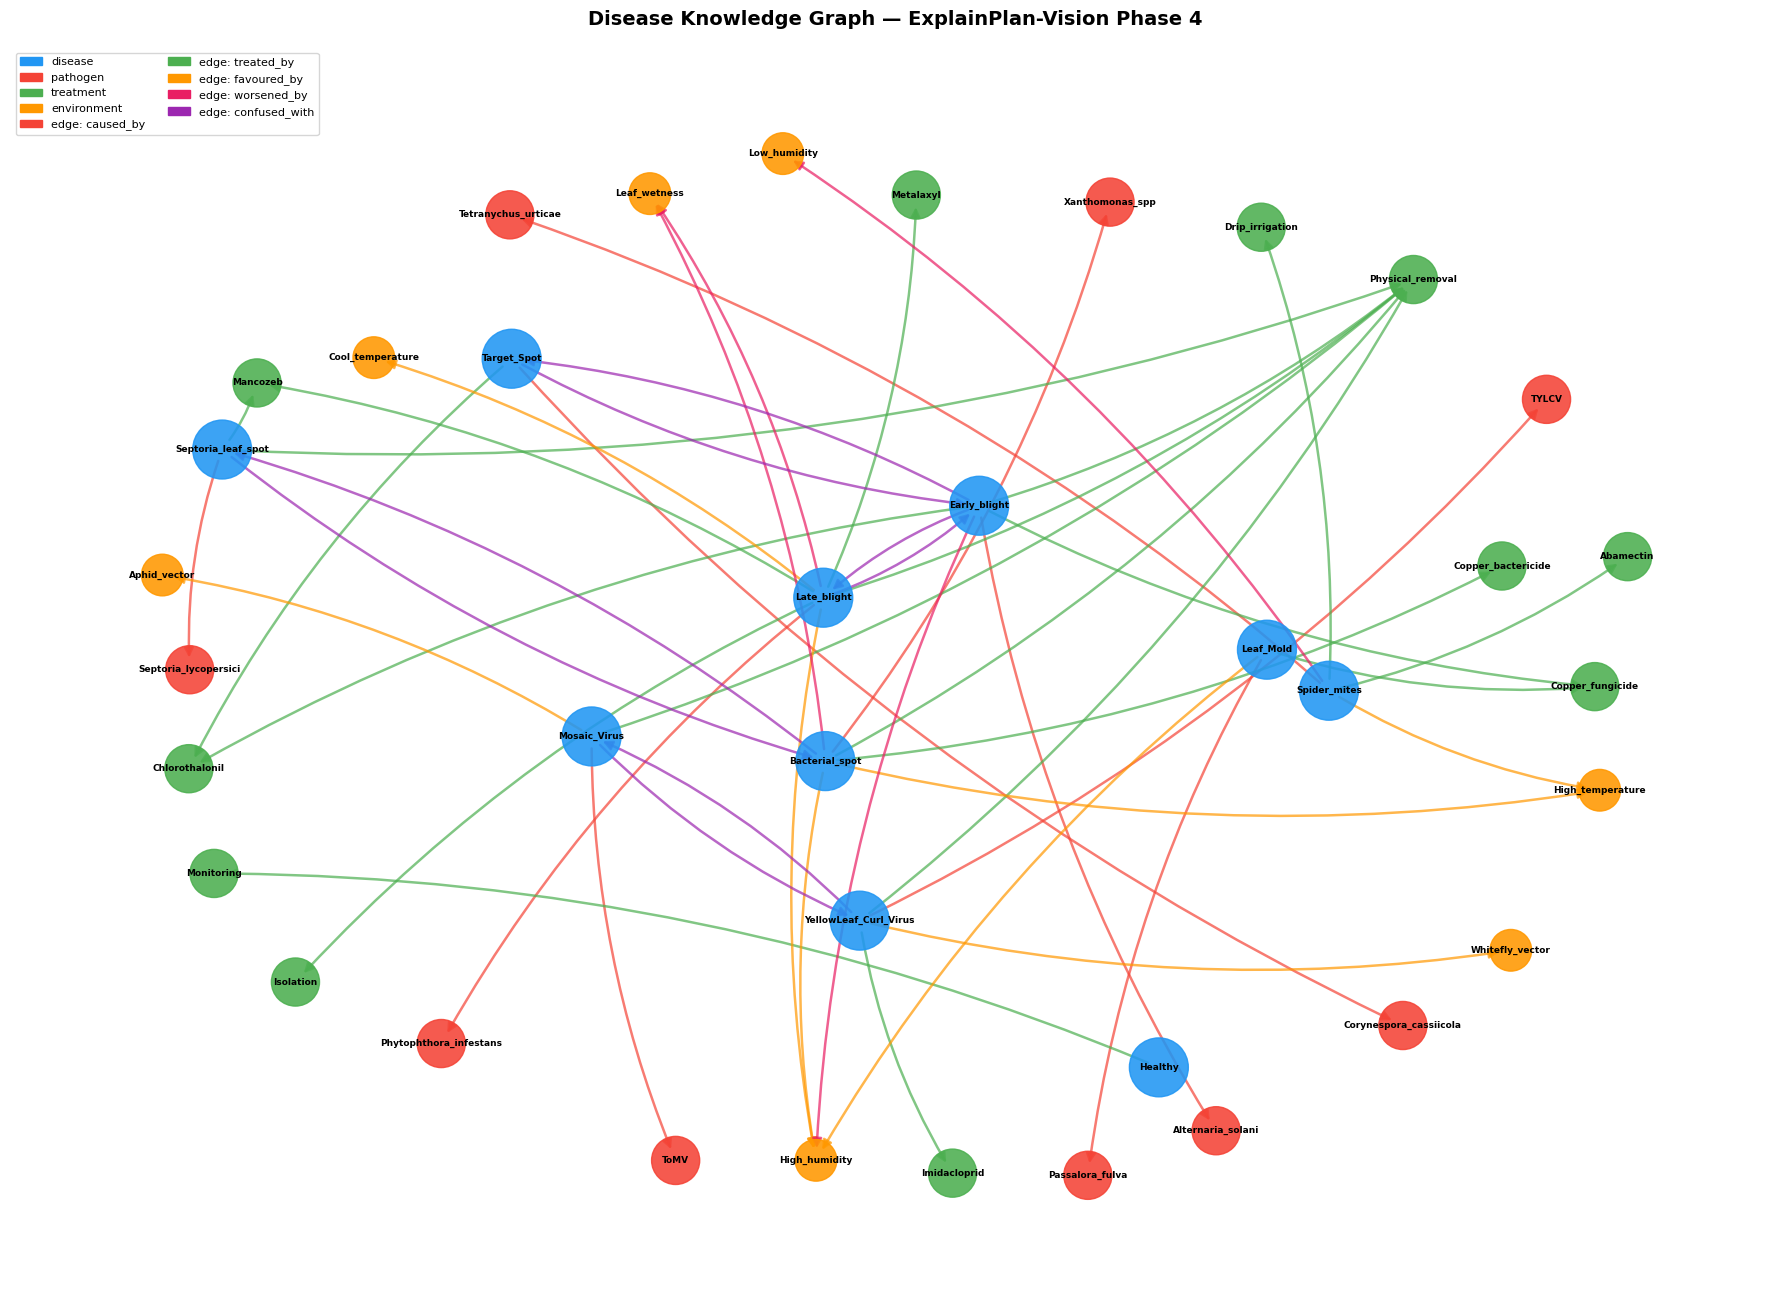

Knowledge graph saved (37 nodes, 48 edges)


In [16]:
fig, ax = plt.subplots(figsize=(18,13))
G   = kg.G
pos = nx.spring_layout(G, k=2.2, seed=42, iterations=80)

node_type_colors = {"disease":"#2196F3","pathogen":"#F44336",
                    "treatment":"#4CAF50","environment":"#FF9800"}
edge_rel_colors  = {"caused_by":"#F44336","treated_by":"#4CAF50",
                    "favoured_by":"#FF9800","worsened_by":"#E91E63","confused_with":"#9C27B0"}

node_colors = [node_type_colors.get(G.nodes[n].get("type","disease"),"#607D8B") for n in G.nodes()]
node_sizes  = [1800 if G.nodes[n].get("type")=="disease" else
               1200 if G.nodes[n].get("type") in ["pathogen","treatment"] else 900 for n in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.88, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=6.5, font_weight="bold", ax=ax)

for rel, color in edge_rel_colors.items():
    edges = [(u,v) for u,v,d in G.edges(data=True) if d.get("relation")==rel]
    if edges:
        nx.draw_networkx_edges(G, pos, edgelist=edges, edge_color=color, alpha=0.7,
                               arrows=True, arrowsize=14, connectionstyle="arc3,rad=0.1",
                               width=1.8, ax=ax)

legend_handles  = [mpatches.Patch(color=c,label=t) for t,c in node_type_colors.items()]
legend_handles += [mpatches.Patch(color=c,label=f"edge: {r}") for r,c in edge_rel_colors.items()]
ax.legend(handles=legend_handles, loc="upper left", fontsize=8, ncol=2)
ax.set_title("Disease Knowledge Graph — ExplainPlan-Vision Phase 4",
             fontsize=14, fontweight="bold", pad=16)
ax.axis("off")
plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/graphs/knowledge_graph.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Knowledge graph saved ({kg.num_nodes} nodes, {kg.num_edges} edges)")

---
## Cell 17 — Reasoning trace visualisation

For each demo case: original image, Grad-CAM overlay, symbolic fact summary,
and top inference results. Primary evidence that the system is reasoning
rather than classifying.

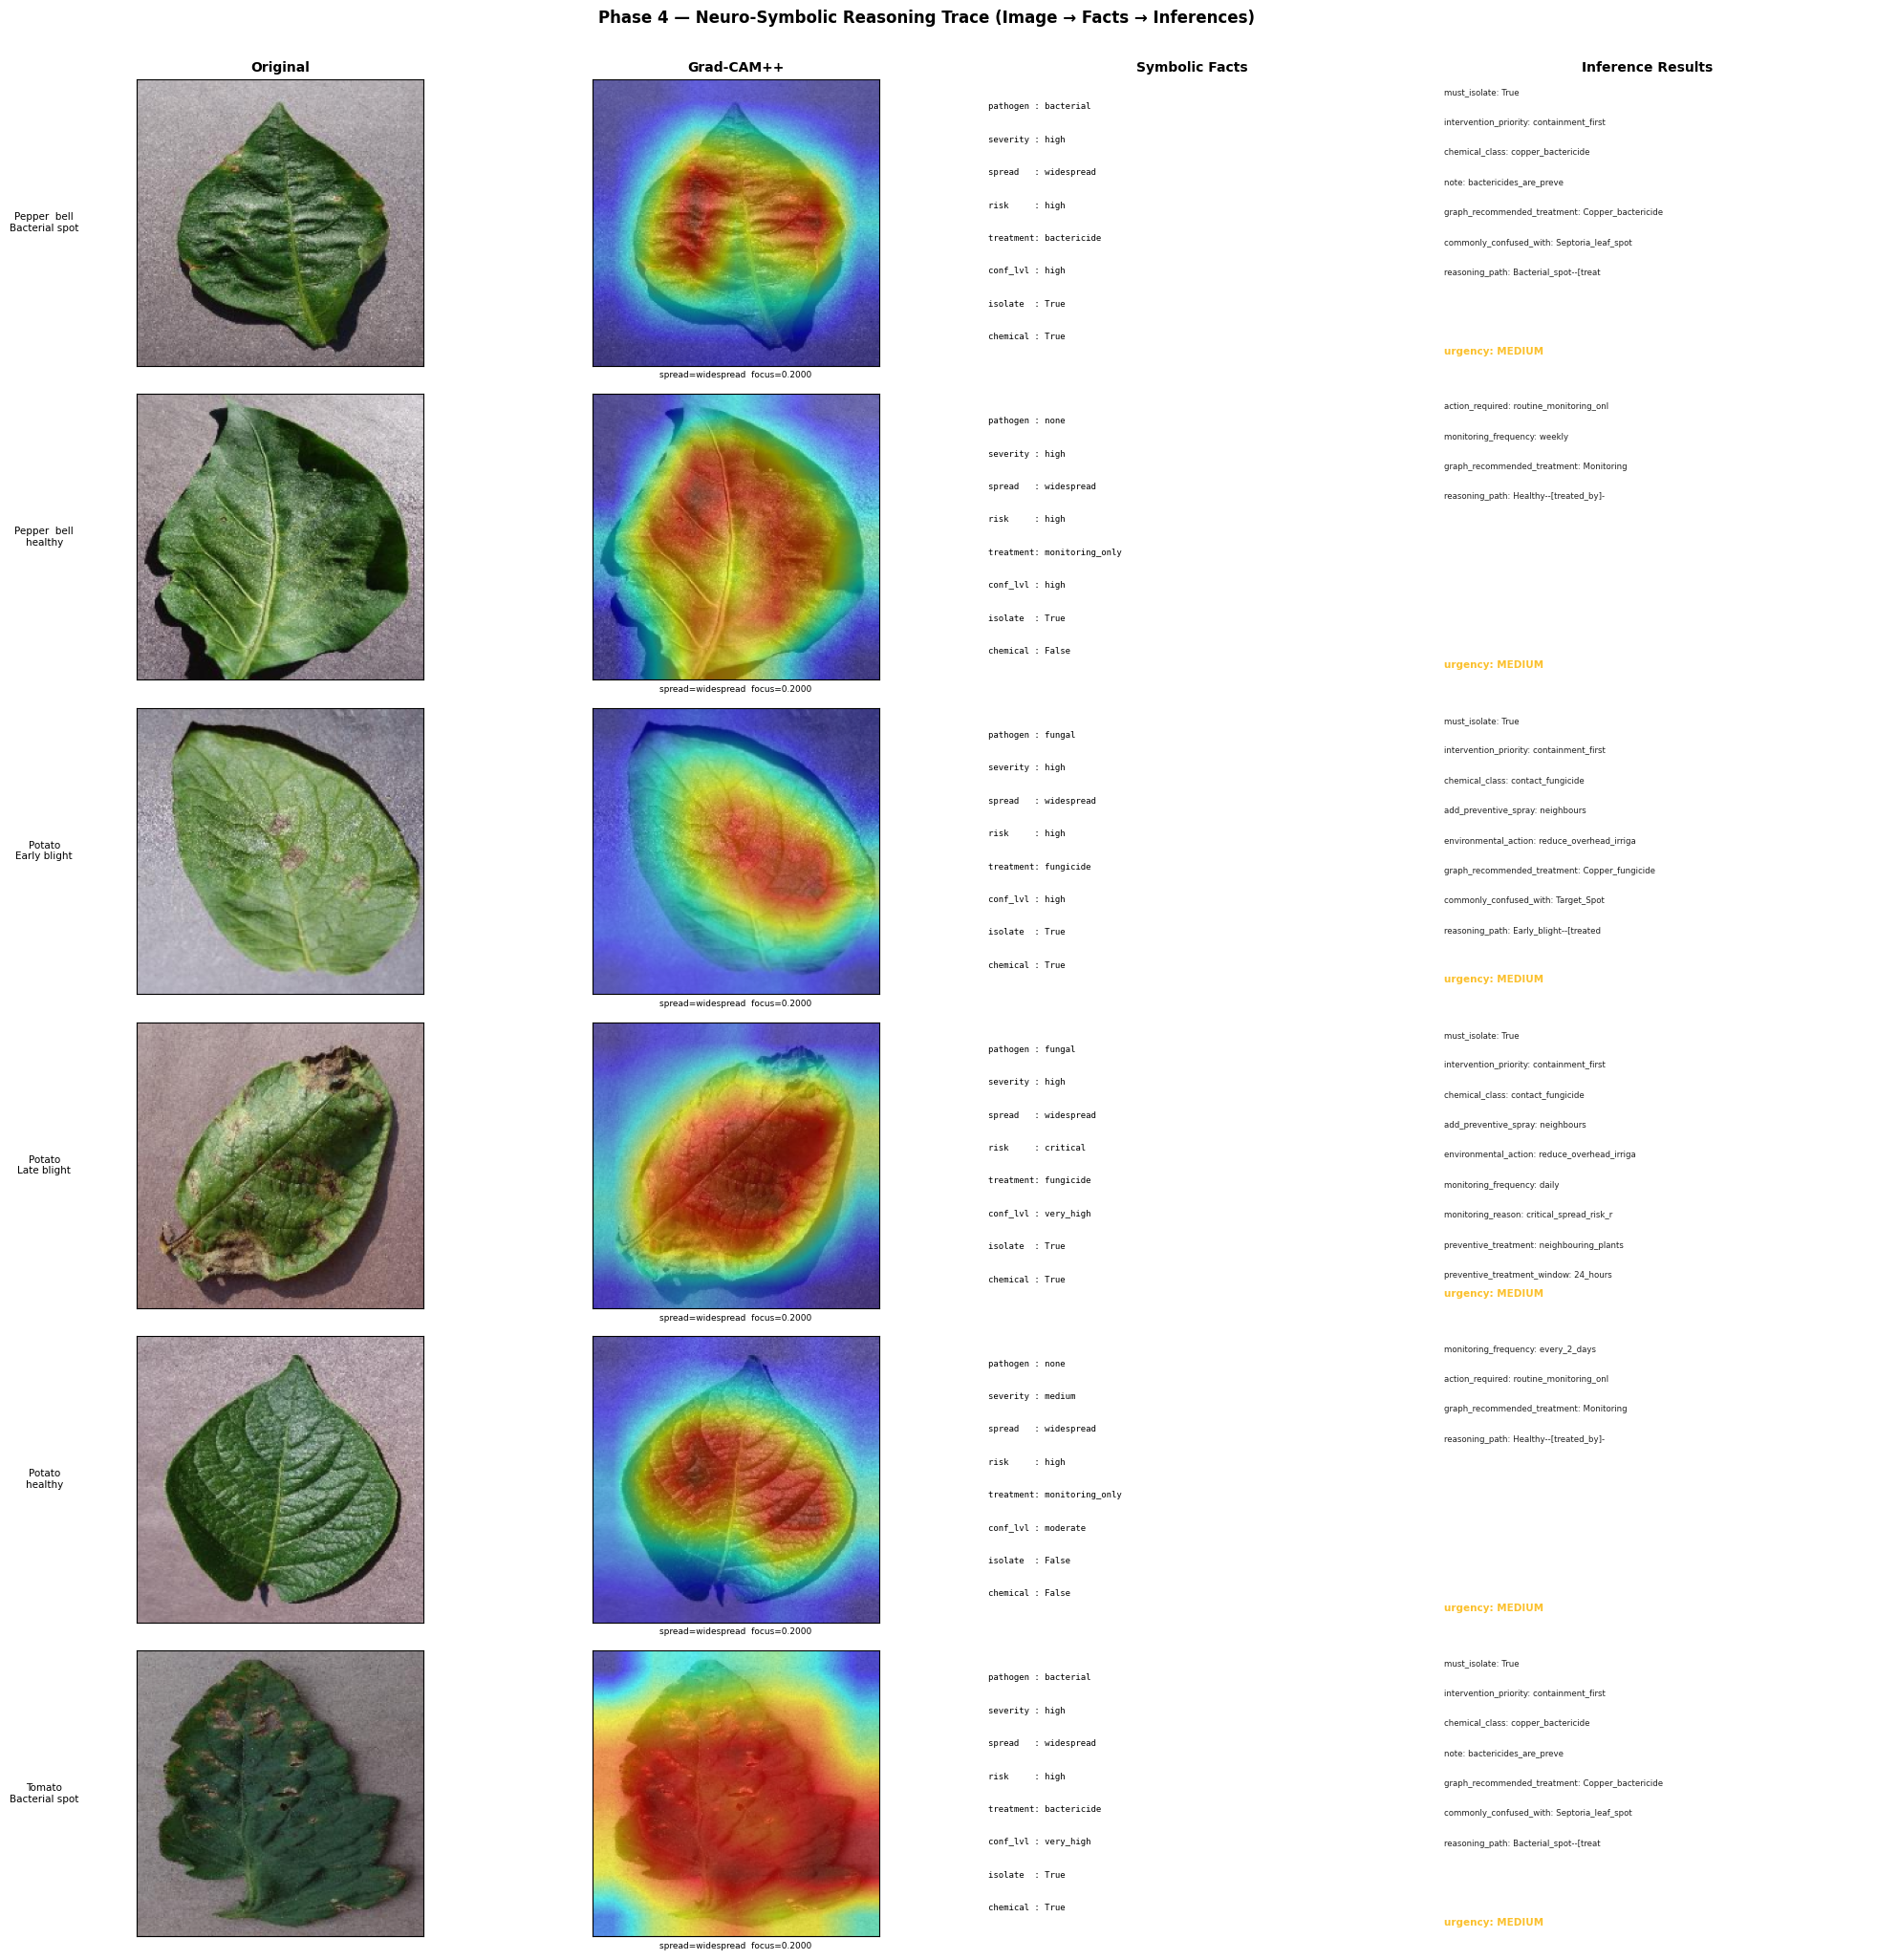

Reasoning trace figure saved


In [17]:
n_show = min(6, len(ns_results))
fig, axes = plt.subplots(n_show, 4, figsize=(20, n_show*3.4))
for j,t in enumerate(["Original","Grad-CAM++","Symbolic Facts","Inference Results"]):
    axes[0,j].set_title(t, fontsize=10, fontweight="bold")

uc_map = {"immediate":"#d32f2f","high":"#f57c00","medium":"#fbc02d",
          "low":"#388e3c","none":"#1976d2","unknown":"#607D8B"}

for i, res in enumerate(ns_results[:n_show]):
    pred    = res["prediction"]
    facts   = res["facts"]
    infs    = res["inferences"]
    fm      = {f.predicate: f.arguments[0] for f in facts}
    urgency = next((inf.arguments[0] for inf in infs if inf.predicate=="urgency_level"),"medium")
    uc      = uc_map.get(urgency,"#607D8B")

    axes[i,0].imshow(cv2.resize(res["image_rgb"],(224,224)))
    axes[i,0].set_ylabel(f"{pred['plant']}\n{pred['disease_type'][:18]}",
                         fontsize=7.5, rotation=0, labelpad=70, va="center")
    axes[i,0].set_xticks([]); axes[i,0].set_yticks([])

    axes[i,1].imshow(res["gradcam_overlay"])
    axes[i,1].set_xlabel(f"spread={fm.get('infection_spread','?')}  focus={fm.get('focus_score','?')}",
                         fontsize=6.5)
    axes[i,1].set_xticks([]); axes[i,1].set_yticks([])

    axes[i,2].axis("off")
    for j2,line in enumerate([f"pathogen : {fm.get('pathogen_type_is','?')}",
                               f"severity : {fm.get('severity_is','?')}",
                               f"spread   : {fm.get('infection_spread','?')}",
                               f"risk     : {fm.get('spread_risk','?')}",
                               f"treatment: {fm.get('treatment_class','?')}",
                               f"conf_lvl : {fm.get('confidence_level','?')}",
                               f"isolate  : {fm.get('requires_isolation','?')}",
                               f"chemical : {fm.get('requires_chemical','?')}"]):
        axes[i,2].text(0.04, 0.92-j2*0.115, line, fontsize=6.5, va="top",
                       transform=axes[i,2].transAxes, family="monospace")
    for sp in axes[i,2].spines.values(): sp.set_visible(True); sp.set_color("#bbb"); sp.set_linewidth(0.8)

    axes[i,3].axis("off")
    shown_p = set(); y = 0.97
    skip    = {"urgency_score","focus_score","top_feature_dims","embedding_norm",
               "embedding_sparsity","peak_activation"}
    for inf in infs:
        if inf.predicate in shown_p or inf.predicate in skip: continue
        axes[i,3].text(0.04, y, f"{inf.predicate}: {inf.arguments[0][:22]}",
                       fontsize=6.2, va="top", transform=axes[i,3].transAxes,
                       color=uc if inf.predicate=="urgency_level" else "#222")
        shown_p.add(inf.predicate); y -= 0.105
        if y < 0.08: break
    axes[i,3].text(0.04, 0.04, f"urgency: {urgency.upper()}",
                   fontsize=7.5, fontweight="bold", color=uc, transform=axes[i,3].transAxes)
    for sp in axes[i,3].spines.values(): sp.set_visible(True); sp.set_color(uc); sp.set_linewidth(1.5)

plt.suptitle("Phase 4 — Neuro-Symbolic Reasoning Trace (Image → Facts → Inferences)",
             fontsize=12, fontweight="bold", y=1.003)
plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/figures/reasoning_trace.png", dpi=150, bbox_inches="tight")
plt.show()
print("Reasoning trace figure saved")

---
## Cell 18 — Counterfactual analysis figure

Side-by-side comparison of original plan vs all four counterfactual scenarios
for the highest-urgency case. Action count delta and urgency change quantify
the value of each intervention lever.

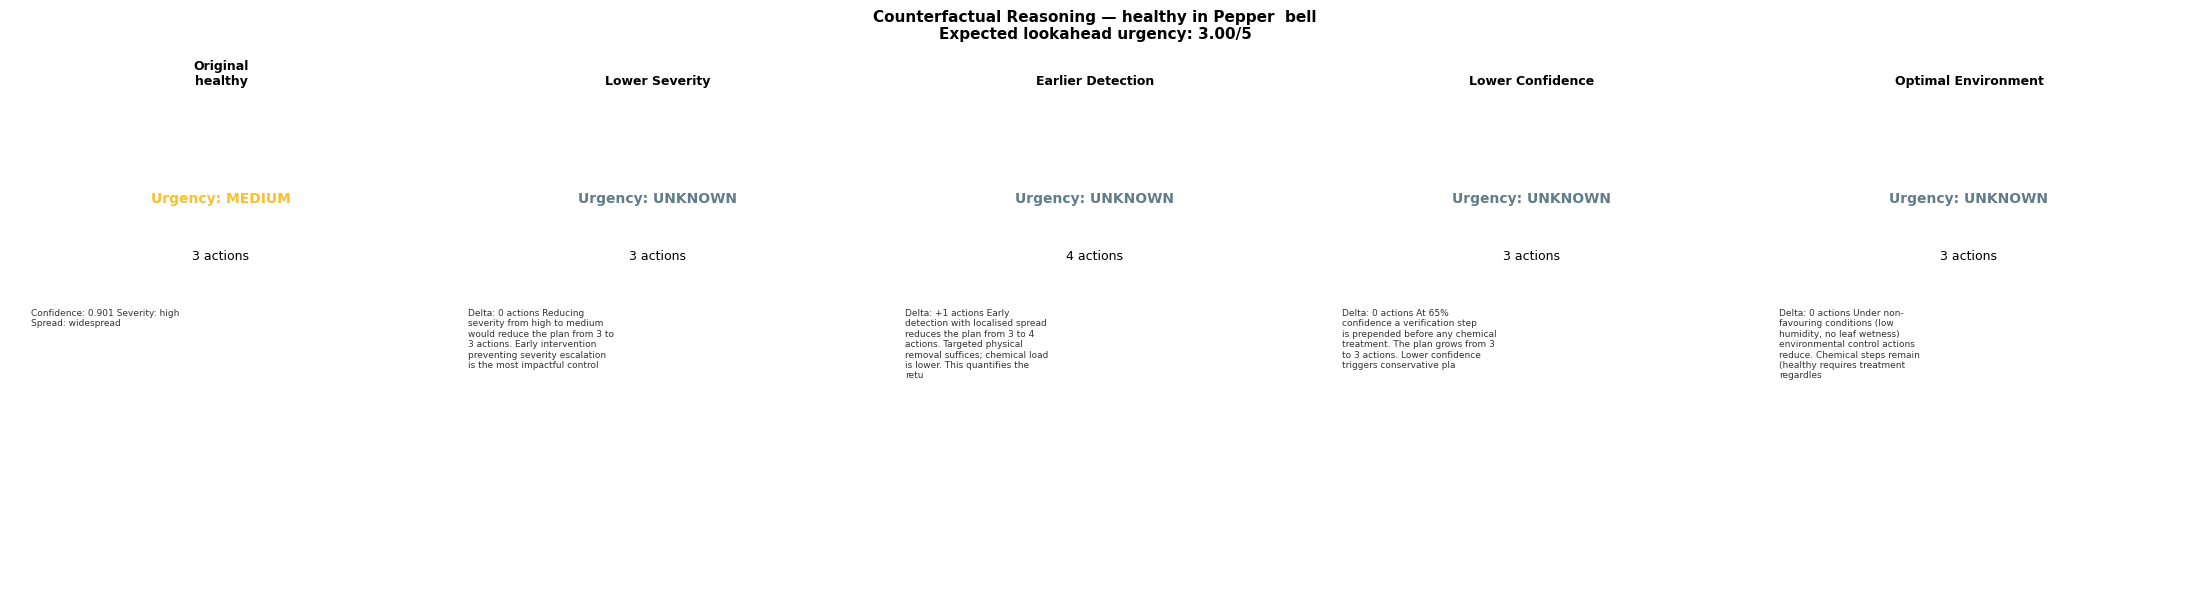

Counterfactual figure saved (demo: healthy)


In [18]:
cf_demo = max(ns_results, key=lambda r: r["expected_urgency"])
pred_cf = cf_demo["prediction"]
cfs     = cf_demo["counterfactuals"]

fig, axes = plt.subplots(1, 5, figsize=(22,6))
uc_map2   = {"immediate":"#d32f2f","high":"#f57c00","medium":"#fbc02d","low":"#388e3c","none":"#1976d2","unknown":"#607D8B"}

def render_card(ax, title, n_actions, urgency, body, is_original=False):
    ax.set_xlim(0,1); ax.set_ylim(0,1); ax.axis("off")
    color = uc_map2.get(urgency,"#607D8B")
    ax.set_title(title, fontsize=9, fontweight="bold")
    ax.text(0.5, 0.80, f"Urgency: {urgency.upper()}", ha="center", va="top",
            fontsize=10, fontweight="bold", color=color, transform=ax.transAxes)
    ax.text(0.5, 0.68, f"{n_actions} actions", ha="center", va="top",
            fontsize=9, transform=ax.transAxes)
    import textwrap
    ax.text(0.05, 0.56, textwrap.fill(body[:280], width=32), ha="left", va="top",
            fontsize=6.5, transform=ax.transAxes, color="#333")
    for sp in ax.spines.values():
        sp.set_visible(True); sp.set_color(color); sp.set_linewidth(3 if is_original else 1.5)

orig_urgency = next((i.arguments[0] for i in cf_demo["inferences"] if i.predicate=="urgency_level"),"medium")
fm_cf = {f.predicate: f.arguments[0] for f in cf_demo["facts"]}
render_card(axes[0], f"Original\n{pred_cf['disease_type'][:22]}",
            len(cf_demo["plan"].full_action_sequence), orig_urgency,
            f"Confidence: {pred_cf['confidence']:.3f}\nSeverity: {pred_cf['severity']}\n"
            f"Spread: {fm_cf.get('infection_spread','?')}", is_original=True)

cf_title_map = {"lower_severity":"Lower Severity","earlier_detection":"Earlier Detection",
                "lower_confidence":"Lower Confidence","optimal_environment":"Optimal Environment"}
for ax, cf in zip(axes[1:], cfs):
    delta_str = f"+{cf['plan_delta']}" if cf["plan_delta"]>0 else str(cf["plan_delta"])
    render_card(ax, cf_title_map.get(cf["scenario"],cf["scenario"]),
                cf["cf_actions"], cf["cf_urgency"],
                f"Delta: {delta_str} actions\n{cf['narrative'][:160]}")

plt.suptitle(f"Counterfactual Reasoning — {pred_cf['disease_type']} in {pred_cf['plant']}\n"
             f"Expected lookahead urgency: {cf_demo['expected_urgency']:.2f}/5",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/figures/counterfactual_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Counterfactual figure saved (demo: {pred_cf['disease_type']})")

---
## Cell 19 — Decision tree visualisation

Multi-step look-ahead tree for the highest-urgency case.

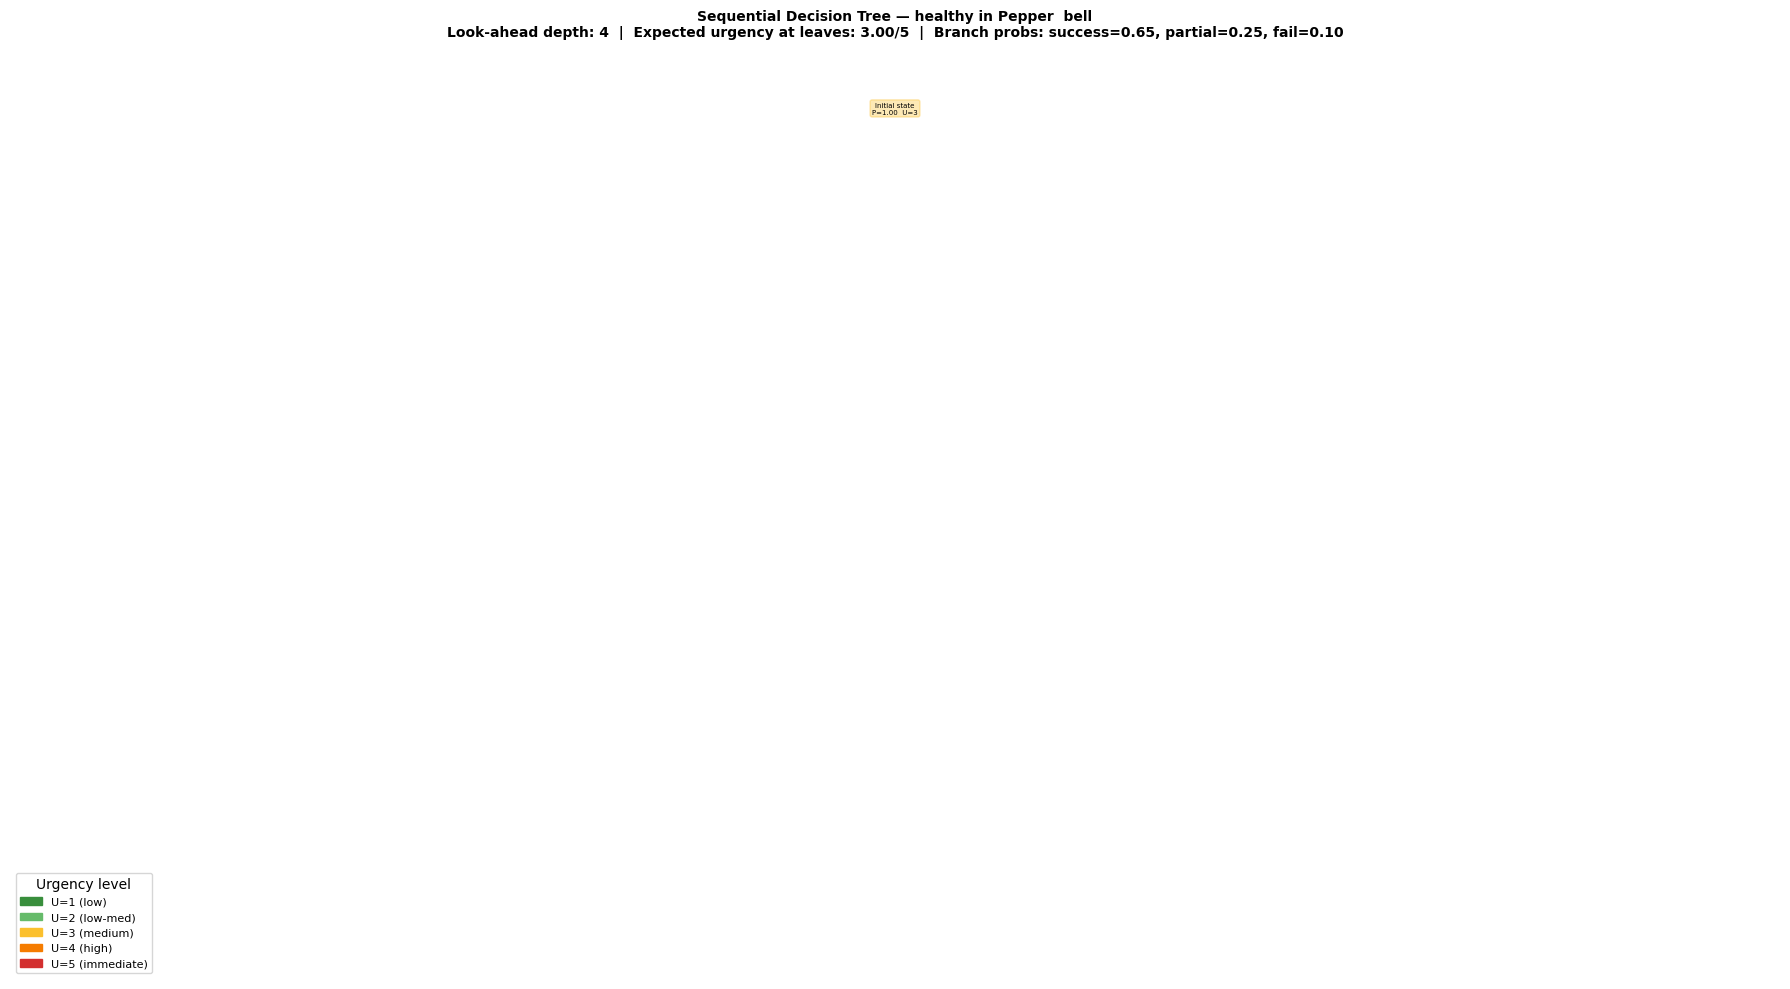

Decision tree figure saved


In [19]:
def draw_tree(ax, node, x=0.5, y=0.94, dx=0.22, dy=0.21, depth=0):
    dt_colors = {1:"#388e3c",2:"#66bb6a",3:"#fbc02d",4:"#f57c00",5:"#d32f2f"}
    color = dt_colors.get(int(node.expected_urgency),"#607D8B")
    label = (node.action[:28]+"..." if len(node.action)>28 else node.action) +             f"\nP={node.probability:.2f}  U={node.expected_urgency:.0f}"
    ax.text(x, y, label, ha="center", va="center", fontsize=5.0,
            transform=ax.transAxes,
            bbox=dict(boxstyle="round,pad=0.3",facecolor=color,alpha=0.35,edgecolor=color))
    if node.children:
        cxs = [x-dx, x, x+dx]
        for child, cx, blabel in zip(node.children, cxs, ["Success","Partial","Fail"]):
            cy = y - dy
            ax.annotate("", xy=(cx,cy+0.04), xytext=(x,y-0.04),
                        xycoords="axes fraction", textcoords="axes fraction",
                        arrowprops=dict(arrowstyle="->",color="#555",lw=1.0))
            ax.text((x+cx)/2,(y+cy)/2+0.005, blabel, ha="center", va="center",
                    fontsize=4.5, color="#666", transform=ax.transAxes)
            draw_tree(ax, child, cx, cy, dx*0.55, dy, depth+1)

fig, ax = plt.subplots(figsize=(18,10))
ax.set_xlim(0,1); ax.set_ylim(0,1); ax.axis("off")
dt_case = max(ns_results, key=lambda r: r["expected_urgency"])
draw_tree(ax, dt_case["decision_tree"])
ax.set_title(
    f"Sequential Decision Tree — {dt_case['prediction']['disease_type']} in {dt_case['prediction']['plant']}\n"
    f"Look-ahead depth: {CONFIG['lookahead_steps']}  |  "
    f"Expected urgency at leaves: {dt_case['expected_urgency']:.2f}/5  |  "
    f"Branch probs: success=0.65, partial=0.25, fail=0.10",
    fontsize=10, fontweight="bold", pad=12)
dt_colors = {1:"#388e3c",2:"#66bb6a",3:"#fbc02d",4:"#f57c00",5:"#d32f2f"}
urgency_labels = {1:"low",2:"low-med",3:"medium",4:"high",5:"immediate"}
legend_handles = [mpatches.Patch(color=c,label=f"U={u} ({urgency_labels[u]})")
                  for u,c in dt_colors.items()]
ax.legend(handles=legend_handles, loc="lower left", fontsize=8, title="Urgency level")
plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/trees/decision_tree.png", dpi=150, bbox_inches="tight")
plt.show()
print("Decision tree figure saved")

---
## Cell 20 — Temporal memory and trend analysis

TEMPORAL MEMORY ANALYSIS
Observations stored : 15
Severity trend      : stable
Urgency trend       : stable
Spread trend        : stable
Disease stable      : False
Summary             : Severity is stable, spread is stable. Urgency stable. Disease varying across recent observations.
Monitoring rec      : Every 2-3 days — monitoring standard for this risk level.


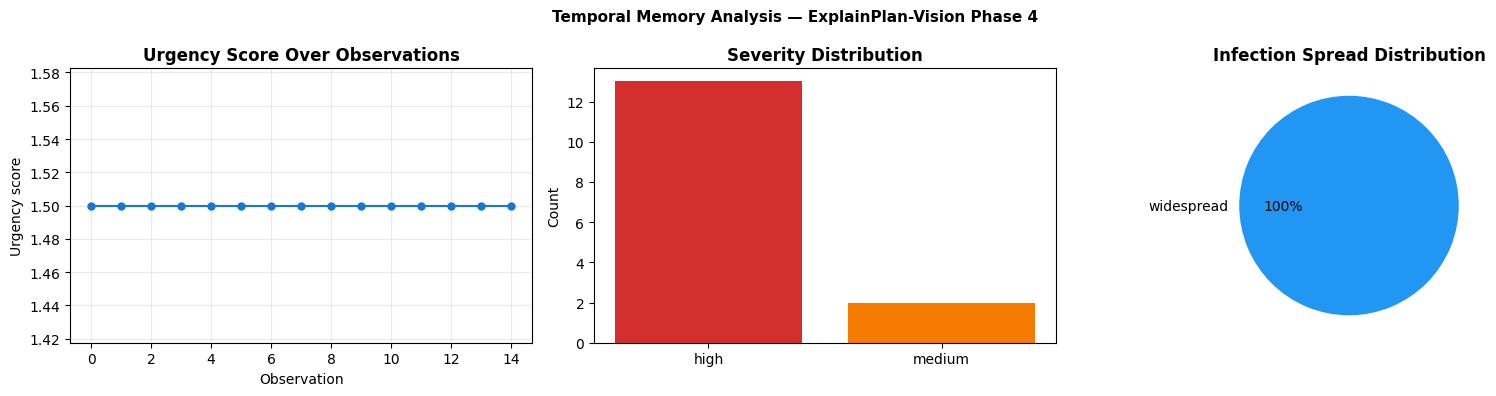

Temporal analysis figure saved


In [20]:
trend_g    = memory.get_trend()
monitor_r  = memory.recommend_monitoring_frequency()
print("TEMPORAL MEMORY ANALYSIS")
print("="*55)
print(f"Observations stored : {len(memory)}")
print(f"Severity trend      : {trend_g['severity_trend']}")
print(f"Urgency trend       : {trend_g['urgency_trend']}")
print(f"Spread trend        : {trend_g['spread_trend']}")
print(f"Disease stable      : {trend_g['disease_stable']}")
print(f"Summary             : {trend_g['summary']}")
print(f"Monitoring rec      : {monitor_r}")

fig, axes = plt.subplots(1,3,figsize=(16,4))
entries = list(memory.entries)
axes[0].plot([e.urgency_score for e in entries], marker="o", color="#1976d2", markersize=5)
axes[0].set_title("Urgency Score Over Observations", fontweight="bold")
axes[0].set_xlabel("Observation"); axes[0].set_ylabel("Urgency score"); axes[0].grid(alpha=0.25)

sev_counts = pd.Series([e.severity for e in entries]).value_counts()
axes[1].bar(sev_counts.index, sev_counts.values, color=["#d32f2f","#f57c00","#388e3c"][:len(sev_counts)])
axes[1].set_title("Severity Distribution", fontweight="bold"); axes[1].set_ylabel("Count")

sp_counts = pd.Series([e.infection_spread for e in entries]).value_counts()
axes[2].pie(sp_counts.values, labels=sp_counts.index, autopct="%1.0f%%",
            colors=["#2196F3","#FF9800","#F44336"][:len(sp_counts)])
axes[2].set_title("Infection Spread Distribution", fontweight="bold")

plt.suptitle("Temporal Memory Analysis — ExplainPlan-Vision Phase 4",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/figures/temporal_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Temporal analysis figure saved")

---
## Cell 21 — Full reasoning report display

In [21]:
highest    = max(ns_results, key=lambda r: r["expected_urgency"])
lowest_c   = min(ns_results, key=lambda r: r["prediction"]["confidence"])
healthy_r  = next((r for r in ns_results if r["prediction"]["is_healthy"]), ns_results[0])

for label, r in [("HIGHEST URGENCY",highest),("LOWEST CONFIDENCE",lowest_c),("HEALTHY PLANT",healthy_r)]:
    print("="*70)
    print(f"CASE: {label}")
    print("="*70)
    print(r["explanations"]["researcher"])
    print()
    print("Farmer summary:")
    print(r["explanations"]["farmer"])
    print()

CASE: HIGHEST URGENCY
ExplainPlan-Vision — Neuro-Symbolic Reasoning Report
VISION MODULE
  Model      : EfficientNet-B0 (Phase 1 checkpoint)
  Disease    : Pepper__bell___healthy
  Confidence : 0.9007
  Severity   : high

XAI MODULE (Grad-CAM++)
  Focus score       : 0.2000
  Infection spread  : widespread
  Spatial complexity: complex
  Activation entropy: 10.6035

SYMBOLIC FACT EXTRACTION
  Total facts: 22
  Pathogen   : none
  Spread risk: high
  Treatment  : monitoring_only
  Isolation  : True

INFERENCE ENGINE OUTPUT
  action_required(routine_monitoring_only) [conf=0.892] via healthy_plant_routine
  monitoring_frequency(weekly) [conf=0.892] via healthy_plant_routine
  graph_recommended_treatment(Monitoring, 1.00) [conf=0.901] via knowledge_graph_traversal
  reasoning_path(Healthy--[treated_by]-->Monitoring) [conf=0.900] via knowledge_graph_path_query

DYNAMIC PLAN
  Actions      : 3
  Adaptations  : 0
  Escalation   : False
  Confidence   : High confidence (90.1%) — plan is reliab

---
## Cell 22 — System-wide analytics table

In [22]:
rows = []
for r in ns_results:
    pred = r["prediction"]; facts = r["facts"]; infs = r["inferences"]; plan = r["plan"]
    fm   = {f.predicate: f.arguments[0] for f in facts}
    im   = {i.predicate: i.arguments[0] for i in infs}
    rows.append({
        "Disease"          : pred["disease_type"],
        "Plant"            : pred["plant"],
        "Confidence"       : pred["confidence"],
        "Severity"         : pred["severity"],
        "Pathogen"         : fm.get("pathogen_type_is","?"),
        "Spread"           : fm.get("infection_spread","?"),
        "Spread risk"      : fm.get("spread_risk","?"),
        "Urgency"          : im.get("urgency_level","?"),
        "Urgency score"    : float(im.get("urgency_score","0")),
        "Actions"          : len(plan.full_action_sequence),
        "Adaptations"      : len(plan.context_adaptations),
        "Escalation"       : plan.escalation_flag,
        "Rules fired"      : len(set(i.rule_fired for i in infs)),
        "Facts extracted"  : len(facts),
        "Expected urgency" : r["expected_urgency"],
    })

analytics_df = pd.DataFrame(rows)
print("Phase 4 System Analytics")
print("="*80)
print(analytics_df[["Disease","Confidence","Severity","Urgency","Urgency score",
                     "Actions","Rules fired","Expected urgency"]].to_string(index=False))
print()
print(f"Mean confidence      : {analytics_df['Confidence'].mean():.4f}")
print(f"Mean rules fired     : {analytics_df['Rules fired'].mean():.1f}")
print(f"Mean facts extracted : {analytics_df['Facts extracted'].mean():.1f}")
print(f"Mean actions planned : {analytics_df['Actions'].mean():.1f}")
print(f"Escalation rate      : {analytics_df['Escalation'].mean():.1%}")
print(f"Mean expected urgency: {analytics_df['Expected urgency'].mean():.3f}/5")
analytics_df.to_csv(f"{CONFIG['output_dir']}/reports/phase4_analytics.csv", index=False)
print("Analytics saved")

Phase 4 System Analytics
                             Disease  Confidence Severity Urgency  Urgency score  Actions  Rules fired  Expected urgency
                      Bacterial spot      0.9030     high       ?            0.0        5            5             1.768
                             healthy      0.9007     high       ?            0.0        3            3             3.000
                        Early blight      0.9095     high       ?            0.0        7            6             1.768
                         Late blight      0.9313     high       ?            0.0        8            9             1.768
                             healthy      0.7892   medium       ?            0.0        3            4             3.000
                      Bacterial spot      0.9304     high       ?            0.0        5            5             1.768
                        Early blight      0.9031     high       ?            0.0        7            6             1.768
       

---
## Cell 23 — Export structured JSON reasoning traces

In [23]:
for r in ns_results:
    pred       = r["prediction"]
    label_safe = pred["disease"].replace("/","_")
    trace = {
        "image_path"      : r["image_path"],
        "prediction"      : {k:v for k,v in pred.items() if k!="embedding"},
        "symbolic_facts"  : [f.to_dict() for f in r["facts"]],
        "inferences"      : [{"predicate":i.predicate,"arguments":i.arguments,
                               "confidence":i.confidence,"rule":i.rule_fired,
                               "support":i.support} for i in r["inferences"]],
        "trend"           : r["trend"],
        "plan"            : {"disease_type":r["plan"].disease_type,
                             "actions":r["plan"].full_action_sequence,
                             "adaptations":r["plan"].context_adaptations,
                             "inference_trace":r["plan"].inference_trace,
                             "escalation_flag":r["plan"].escalation_flag,
                             "confidence_note":r["plan"].confidence_note,
                             "monitoring_interval":r["plan"].monitoring_interval},
        "counterfactuals" : [{k:v for k,v in cf.items() if k!="cf_plan"} for cf in r["counterfactuals"]],
        "decision_tree"   : dt_planner.tree_to_dict(r["decision_tree"]),
        "expected_urgency": r["expected_urgency"],
        "explanations"    : r["explanations"],
    }
    with open(f"{CONFIG['output_dir']}/traces/{label_safe}_ns_trace.json","w") as f:
        json.dump(trace, f, indent=2, default=str)

with open(f"{CONFIG['output_dir']}/reports/temporal_memory.json","w") as f:
    json.dump(memory.to_list(), f, indent=2, default=str)

api_schema = {
    "description" : "Phase 4 NS Agent output schema — interface to Phase 5 FastAPI",
    "endpoint"    : "POST /api/v1/ns_analyse",
    "output_fields": {
        "prediction"       : "disease, confidence, severity, is_healthy, ...",
        "symbolic_facts"   : "List of SymbolicFact (predicate, arguments, confidence, source)",
        "inferences"       : "List of InferenceFact (predicate, arguments, rule_fired, support)",
        "trend"            : "TemporalMemory trend dict",
        "plan"             : "ContextualPlan (actions, adaptations, escalation_flag, ...)",
        "counterfactuals"  : "4 scenarios (lower_severity, earlier_detection, lower_confidence, optimal_environment)",
        "decision_tree"    : "Nested dict (step, action, probability, urgency, children)",
        "expected_urgency" : "Float in [1,5] — probability-weighted leaf urgency",
        "explanations"     : "farmer | agronomist | researcher",
    }
}
with open(f"{CONFIG['output_dir']}/reports/api_schema.json","w") as f:
    json.dump(api_schema, f, indent=2)

print(f"Exported {len(ns_results)} reasoning trace JSON files")
print(f"Temporal memory saved ({len(memory)} entries)")
print()
for root, dirs, files in os.walk(CONFIG["output_dir"]):
    level  = root.replace(CONFIG["output_dir"],"").count(os.sep)
    indent = "  "*level
    print(f"{indent}{os.path.basename(root)}/")
    for fname in files:
        sz = os.path.getsize(os.path.join(root,fname))
        print(f"  {indent}{fname}  ({sz:,} bytes)")

Exported 15 reasoning trace JSON files
Temporal memory saved (15 entries)

ns_reasoning/
  figures/
    counterfactual_analysis.png  (120,861 bytes)
    temporal_analysis.png  (72,921 bytes)
    reasoning_trace.png  (4,160,969 bytes)
  reports/
    phase4_analytics.csv  (1,444 bytes)
    temporal_memory.json  (9,880 bytes)
    api_schema.json  (851 bytes)
  graphs/
    knowledge_graph.png  (740,355 bytes)
  trees/
    decision_tree.png  (63,110 bytes)
  traces/
    Potato___Late_blight_ns_trace.json  (36,861 bytes)
    Tomato_Early_blight_ns_trace.json  (34,174 bytes)
    Potato___healthy_ns_trace.json  (13,771 bytes)
    Tomato_Spider_mites_Two_spotted_spider_mite_ns_trace.json  (31,079 bytes)
    Tomato__Tomato_YellowLeaf__Curl_Virus_ns_trace.json  (38,299 bytes)
    Tomato__Tomato_mosaic_virus_ns_trace.json  (33,275 bytes)
    Pepper__bell___Bacterial_spot_ns_trace.json  (31,486 bytes)
    Tomato_Late_blight_ns_trace.json  (36,632 bytes)
    Pepper__bell___healthy_ns_trace.json  (13

## Cell 24 — Phase 4 summary and bridge to Phase 5

### What Phase 4 delivers

| Module | Class | Research contribution |
|--------|-------|-----------------------|
| Symbolic Fact Extractor | SymbolicFactExtractor | Neuro-symbolic grounding — neural outputs to typed predicates |
| Disease Knowledge Graph | DiseaseKnowledgeGraph | 40-node typed graph with path queries |
| Forward-chaining Reasoner | NeuroSymbolicReasoner | 20 inference rules + knowledge graph traversal |
| Temporal Memory | TemporalMemory | Rolling state history with trend analysis |
| Context Engine | ContextEngine | Situation-aware dynamic plan adaptation |
| Causal Reasoner | CausalReasoner | 4 counterfactual scenarios per observation |
| Decision Tree Planner | DecisionTreePlanner | Multi-step look-ahead with probabilistic outcomes |
| NS Explainer | NSExplainer | Three-mode adaptive explanation from the same trace |
| Unified Agent | run_ns_agent() | 12-stage pipeline from image to structured report |

### Research positioning after Phase 4

The system now spans:
- Computer vision (Phase 1)
- Explainable AI — three XAI methods (Phase 2)
- Rule-based sequential planning (Phase 3)
- Neuro-symbolic grounding and forward-chaining inference (Phase 4)
- Knowledge graph relational reasoning (Phase 4)
- Temporal memory and trend-aware adaptation (Phase 4)
- Probabilistic multi-step decision making (Phase 4)
- Causal and counterfactual reasoning (Phase 4)

### Bridge to Phase 5 — FastAPI deployment

The `run_ns_agent()` function is already structured as an API endpoint.
The `api_schema.json` saved in Cell 23 documents the exact request/response format.
Phase 5 wraps this function in FastAPI, adds image upload handling, and deploys
to Hugging Face Spaces.

### Bridge to Phase 6 — LLM integration

The explanations produced by NSExplainer are deterministic templates grounded
in the inference trace. Phase 6 feeds these templates into a language model as
structured context, allowing refinement of language while keeping reasoning
grounded. The LLM can only elaborate on facts the rule engine has already verified.

---

**GitHub note:** Commit as `notebooks/phase4_neurosymbolic_reasoning.ipynb`.  
Save `outputs/ns_reasoning/` as Kaggle dataset `explainplan-phase4-outputs` for Phase 5.